In [ ]:
!pip install -qq "numpy<2"

In [ ]:
!pip install -qq mediapipe==0.10.14


2026-06-02 07:34:05.830103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780385646.013599     120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780385646.067555     120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780385646.531419     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780385646.531460     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780385646.531463     120 computation_placer.cc:177] computation placer alr

Extracting landmarks from images...
  chair_pose: 20 valid skeletons extracted
  dolphin_plank_pose: 20 valid skeletons extracted
  downward-facing_dog_pose: 20 valid skeletons extracted
  fish_pose: 18 valid skeletons extracted
  goddess_pose: 20 valid skeletons extracted
  locust_pose: 20 valid skeletons extracted
  lord_of_the_dance_pose: 20 valid skeletons extracted
  low_lunge_pose: 20 valid skeletons extracted
  seated_forward_bend_pose: 18 valid skeletons extracted
  side_plank_pose: 20 valid skeletons extracted
  staff_pose: 18 valid skeletons extracted
  tree_pose: 20 valid skeletons extracted
  warrior_1_pose: 20 valid skeletons extracted
  warrior_2_pose: 20 valid skeletons extracted
  warrior_3_pose: 20 valid skeletons extracted
  wide-angle_seated_forward_bend_pose: 20 valid skeletons extracted


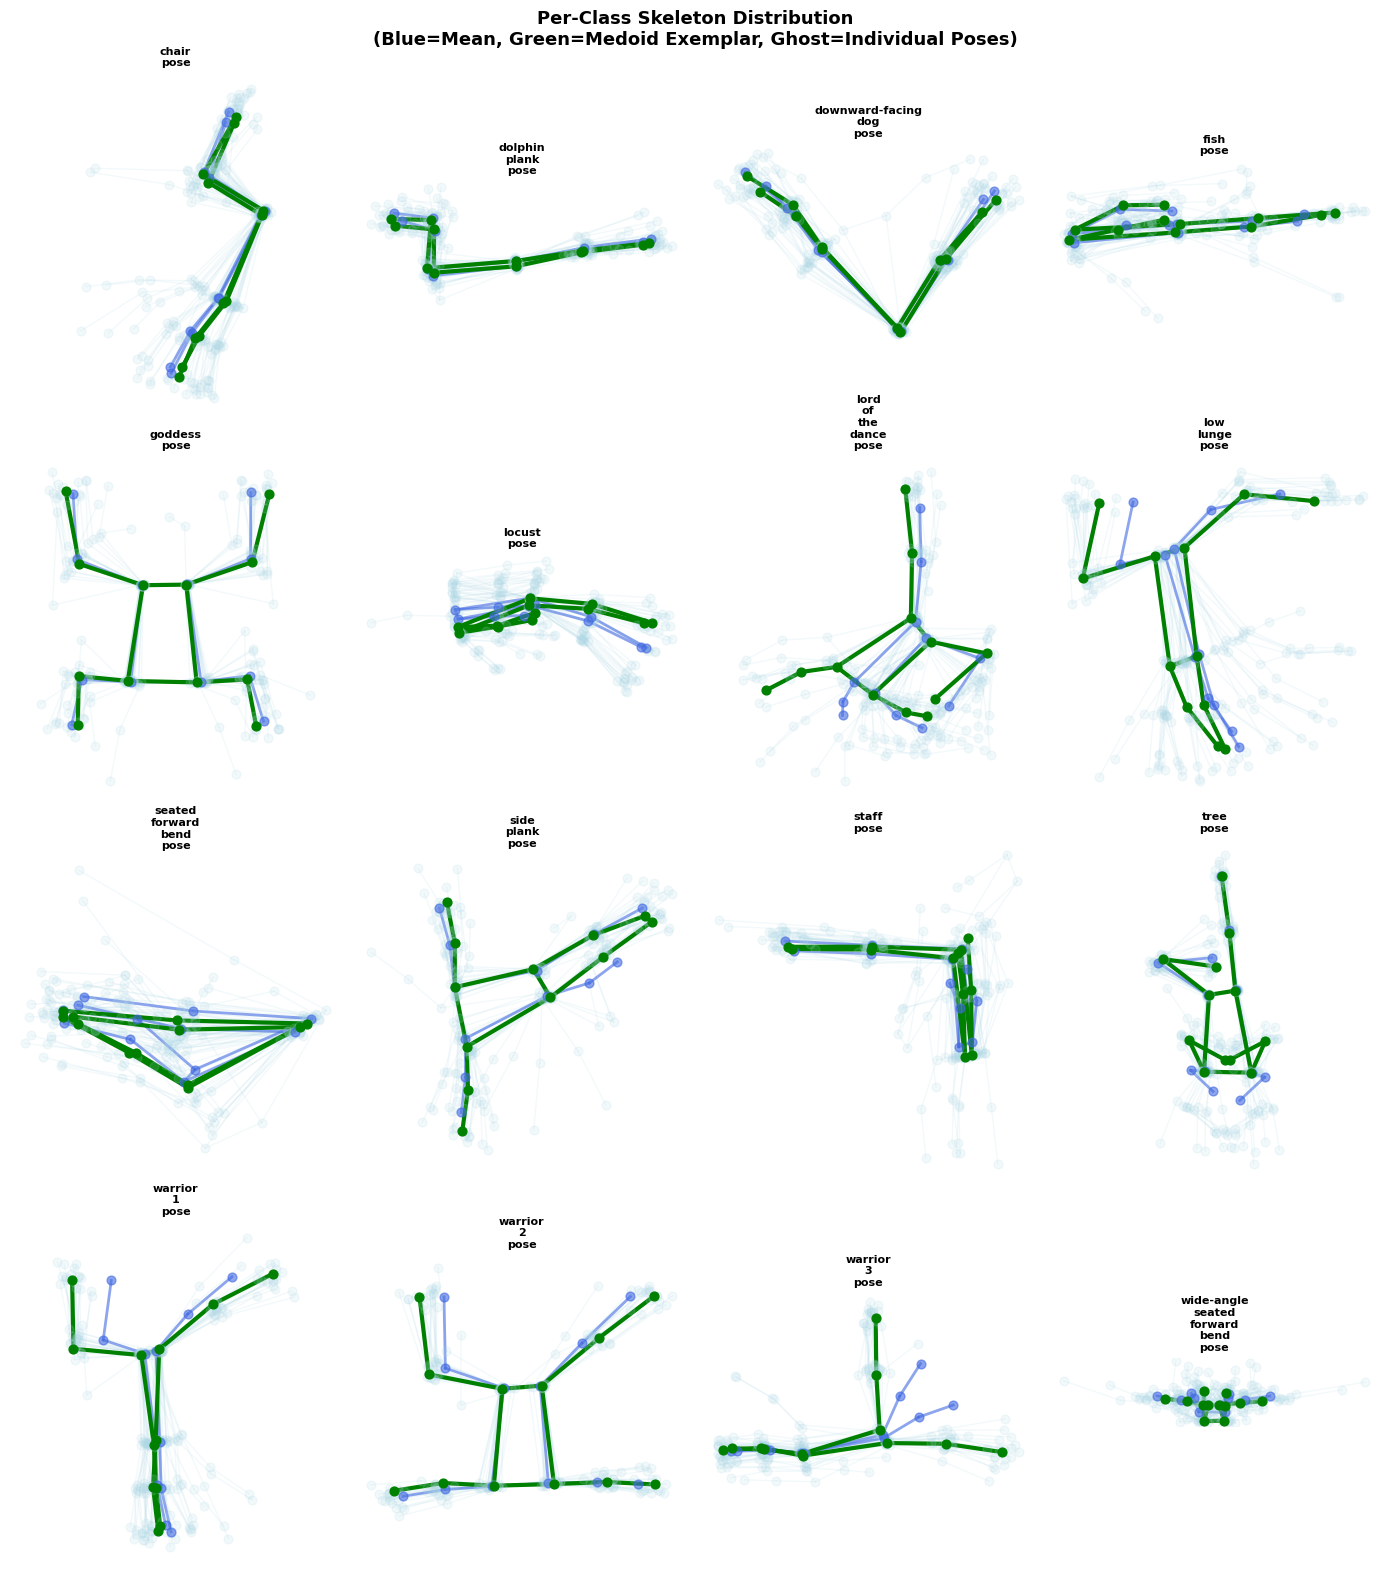

✅ Saved: class_skeleton_overview.png


/tmp/ipykernel_120/1311813344.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(JOINT_NAMES, rotation=45, ha='right', fontsize=10)


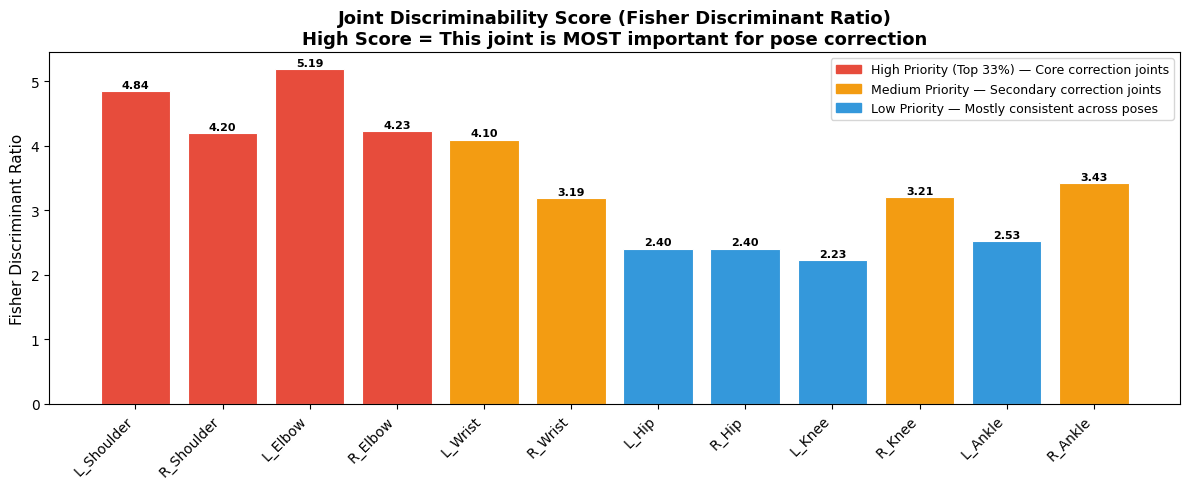

✅ Saved: joint_discriminability.png


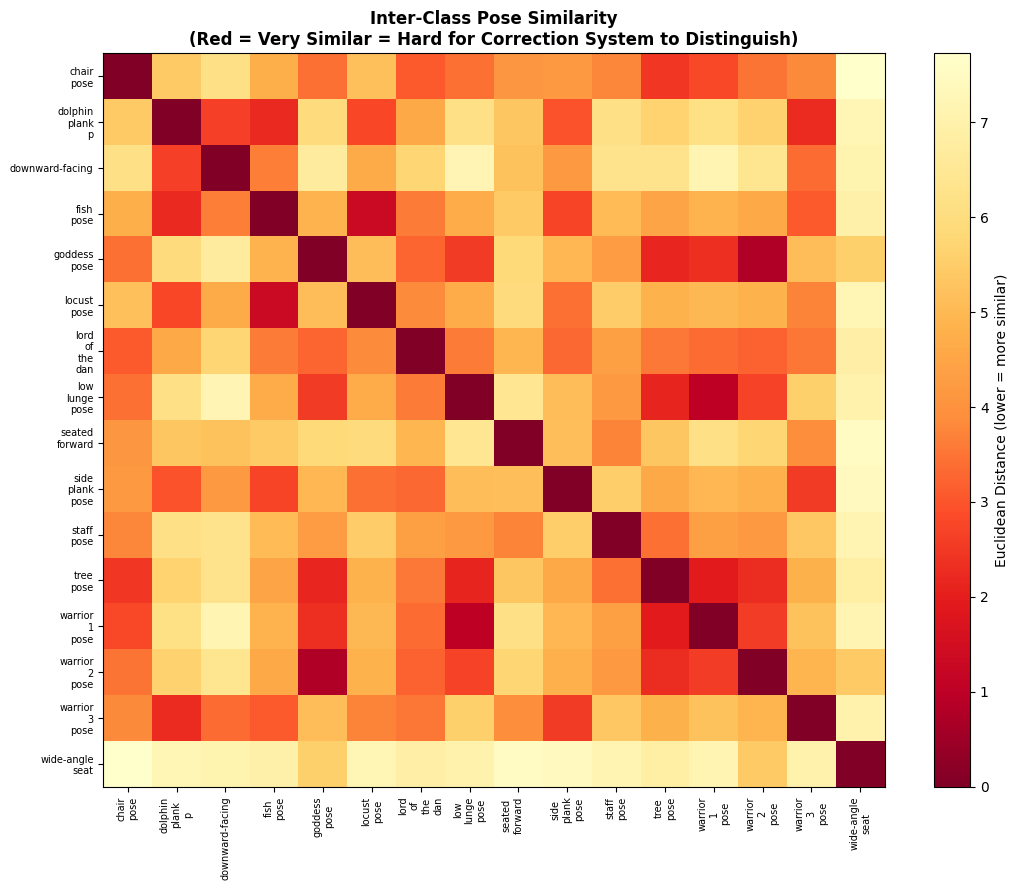

✅ Saved: interclass_similarity.png

EXPLORATION SUMMARY
  🔴 HIGH | L_Shoulder      | FDR = 4.844
  🔴 HIGH | R_Shoulder      | FDR = 4.202
  🔴 HIGH | L_Elbow         | FDR = 5.193
  🔴 HIGH | R_Elbow         | FDR = 4.226
  🟡 MED  | L_Wrist         | FDR = 4.096
  🟡 MED  | R_Wrist         | FDR = 3.186
  🔵 LOW  | L_Hip           | FDR = 2.405
  🔵 LOW  | R_Hip           | FDR = 2.405
  🔵 LOW  | L_Knee          | FDR = 2.231
  🟡 MED  | R_Knee          | FDR = 3.207
  🔵 LOW  | L_Ankle         | FDR = 2.526
  🟡 MED  | R_Ankle         | FDR = 3.425
Top correction joints: ['L_Elbow', 'L_Shoulder', 'R_Elbow', 'R_Shoulder']


In [1]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from scipy.spatial.distance import cdist

# ─── CONFIG ────────────────────────────────────────────────
DATASET_ROOT = '/kaggle/input/datasets/mohiuddin2531/yoga-16/yoga16-dataset/train'
MAX_IMAGES_PER_CLASS = 20  

# The 12 relevant joints (indices into MediaPipe's 33 landmarks)
RELEVANT_JOINTS = {
    'L_Shoulder': 11, 'R_Shoulder': 12,
    'L_Elbow': 13,    'R_Elbow': 14,
    'L_Wrist': 15,    'R_Wrist': 16,
    'L_Hip': 23,      'R_Hip': 24,
    'L_Knee': 25,     'R_Knee': 26,
    'L_Ankle': 27,    'R_Ankle': 28,
}
JOINT_NAMES = list(RELEVANT_JOINTS.keys())
JOINT_IDX   = list(RELEVANT_JOINTS.values())

# MediaPipe skeleton connections (between our 12 joints only)
CONNECTIONS = [
    (0, 1),  # Shoulders
    (0, 2),  # L_Shoulder - L_Elbow
    (2, 4),  # L_Elbow - L_Wrist
    (1, 3),  # R_Shoulder - R_Elbow
    (3, 5),  # R_Elbow - R_Wrist
    (0, 6),  # L_Shoulder - L_Hip
    (1, 7),  # R_Shoulder - R_Hip
    (6, 7),  # Hips
    (6, 8),  # L_Hip - L_Knee
    (8, 10), # L_Knee - L_Ankle
    (7, 9),  # R_Hip - R_Knee
    (9, 11), # R_Knee - R_Ankle
]

# ─── STEP 1: EXTRACT + NORMALIZE LANDMARKS ─────────────────
def extract_landmarks(image_path, pose_estimator):
    img = cv2.imread(image_path)
    if img is None: return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = pose_estimator.process(img_rgb)
    if not result.pose_landmarks: return None
    
    h, w = img.shape[:2]
    all_lm = result.pose_landmarks.landmark
    
    # Extract only the 12 relevant joints
    pts = np.array([[all_lm[i].x * w, all_lm[i].y * h] 
                    for i in JOINT_IDX], dtype=np.float32)
    vis = np.array([all_lm[i].visibility for i in JOINT_IDX])
    
    # Check enough joints are visible (visibility > 0.5)
    if np.mean(vis > 0.5) < 0.6: return None
    return pts


def normalize_skeleton(pts):
    """
    Normalize skeleton to be body-size and position invariant.
    1. Translate: hip midpoint to origin
    2. Scale: divide by torso length (hip-mid to shoulder-mid)
    """
    hip_mid = (pts[6] + pts[7]) / 2.0          # L_Hip, R_Hip average
    shoulder_mid = (pts[0] + pts[1]) / 2.0      # L_Shoulder, R_Shoulder average
    
    torso_length = np.linalg.norm(shoulder_mid - hip_mid)
    if torso_length < 1e-6: return None
    
    normalized = (pts - hip_mid) / torso_length
    return normalized


# ─── STEP 2: BUILD PER-CLASS SKELETON LIBRARY ──────────────
mp_pose = mp.solutions.pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

class_skeletons = defaultdict(list)
class_names = sorted(os.listdir(DATASET_ROOT))

print("Extracting landmarks from images...")
for class_name in class_names:
    class_dir = os.path.join(DATASET_ROOT, class_name)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    images = images[:MAX_IMAGES_PER_CLASS]
    
    for img_file in images:
        img_path = os.path.join(class_dir, img_file)
        pts = extract_landmarks(img_path, mp_pose)
        if pts is None: continue
        norm_pts = normalize_skeleton(pts)
        if norm_pts is None: continue
        class_skeletons[class_name].append(norm_pts)
    
    print(f"  {class_name}: {len(class_skeletons[class_name])} valid skeletons extracted")

mp_pose.close()

# ─── STEP 3: COMPUTE MEDOID EXEMPLARS ──────────────────────
class_exemplars = {}
for class_name, skeletons in class_skeletons.items():
    if len(skeletons) < 3: continue
    flat = np.array([s.flatten() for s in skeletons])
    dist_matrix = cdist(flat, flat, metric='euclidean')
    medoid_idx = np.argmin(dist_matrix.sum(axis=1))
    class_exemplars[class_name] = skeletons[medoid_idx]

# ─── STEP 4: VISUALIZE AVERAGE SKELETONS PER CLASS ─────────
def draw_skeleton(ax, pts, title, color='royalblue', alpha=1.0, linewidth=2):
    for i, j in CONNECTIONS:
        ax.plot([pts[i, 0], pts[j, 0]], [pts[i, 1], pts[j, 1]],
                color=color, alpha=alpha, linewidth=linewidth)
    ax.scatter(pts[:, 0], pts[:, 1], s=40, color=color, zorder=5, alpha=alpha)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')

valid_classes = [c for c in class_names if len(class_skeletons[c]) >= 3]
n_classes = len(valid_classes)
ncols = 4
nrows = (n_classes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 4))
axes = axes.flatten()

for ax_idx, class_name in enumerate(valid_classes):
    skeletons = np.array(class_skeletons[class_name])
    mean_skeleton = skeletons.mean(axis=0)
    exemplar = class_exemplars[class_name]
    
    # Draw ALL individual skeletons faintly (distribution)
    for skel in skeletons:
        draw_skeleton(axes[ax_idx], skel, '', color='lightblue', alpha=0.15, linewidth=1)
    
    # Draw the MEAN skeleton
    draw_skeleton(axes[ax_idx], mean_skeleton, '', color='royalblue', alpha=0.6, linewidth=2)
    
    # Draw the MEDOID EXEMPLAR in bold green
    draw_skeleton(axes[ax_idx], exemplar, class_name.replace('_', '\n'), 
                  color='green', alpha=1.0, linewidth=3)

for ax_idx in range(len(valid_classes), len(axes)):
    axes[ax_idx].axis('off')

fig.suptitle("Per-Class Skeleton Distribution\n(Blue=Mean, Green=Medoid Exemplar, Ghost=Individual Poses)", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_skeleton_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: class_skeleton_overview.png")

# ─── STEP 5: JOINT DISCRIMINABILITY SCORE ──────────────────
# Fisher Discriminant Ratio per joint tells us which joints are most
# useful for pose correction (high inter-class variance, low intra-class variance)

all_skeletons_flat = []
all_labels = []
for class_idx, class_name in enumerate(valid_classes):
    for skel in class_skeletons[class_name]:
        all_skeletons_flat.append(skel.flatten())
        all_labels.append(class_idx)

all_skeletons_flat = np.array(all_skeletons_flat)
all_labels = np.array(all_labels)

# Compute Fisher Discriminant Ratio (FDR) per joint
fdr_scores = []
for j in range(12):
    joint_coords = all_skeletons_flat[:, j*2:(j+1)*2]  # x, y for joint j
    
    overall_mean = joint_coords.mean(axis=0)
    
    between_class_var = 0
    within_class_var = 0
    
    for class_idx in range(len(valid_classes)):
        class_mask = all_labels == class_idx
        if class_mask.sum() < 2: continue
        class_data = joint_coords[class_mask]
        class_mean = class_data.mean(axis=0)
        n_c = class_mask.sum()
        
        between_class_var += n_c * np.sum((class_mean - overall_mean)**2)
        within_class_var  += np.sum((class_data - class_mean)**2)
    
    fdr = between_class_var / (within_class_var + 1e-8)
    fdr_scores.append(fdr)

# ─── STEP 6: PLOT JOINT DISCRIMINABILITY ───────────────────
colors = ['#e74c3c' if s > np.percentile(fdr_scores, 66) else 
          '#f39c12' if s > np.percentile(fdr_scores, 33) else '#3498db' 
          for s in fdr_scores]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(JOINT_NAMES, fdr_scores, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title("Joint Discriminability Score (Fisher Discriminant Ratio)\n"
             "High Score = This joint is MOST important for pose correction", 
             fontsize=13, fontweight='bold')
ax.set_ylabel("Fisher Discriminant Ratio", fontsize=11)
ax.set_xticklabels(JOINT_NAMES, rotation=45, ha='right', fontsize=10)

# Add value labels on bars
for bar, score in zip(bars, fdr_scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{score:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High Priority (Top 33%) — Core correction joints'),
    mpatches.Patch(color='#f39c12', label='Medium Priority — Secondary correction joints'),
    mpatches.Patch(color='#3498db', label='Low Priority — Mostly consistent across poses'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('joint_discriminability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: joint_discriminability.png")

# ─── STEP 7: INTER-CLASS DISTANCE HEATMAP ──────────────────
# Shows which pose pairs are most SIMILAR to each other
# (These are the hardest cases for the correction system!)
class_mean_skeletons = {c: np.array(class_skeletons[c]).mean(axis=0).flatten() 
                        for c in valid_classes}
n = len(valid_classes)
dist_matrix = np.zeros((n, n))

for i, c1 in enumerate(valid_classes):
    for j, c2 in enumerate(valid_classes):
        dist_matrix[i, j] = np.linalg.norm(
            class_mean_skeletons[c1] - class_mean_skeletons[c2]
        )

fig, ax = plt.subplots(figsize=(11, 9))
short_names = [c.replace('_', '\n')[:15] for c in valid_classes]
im = ax.imshow(dist_matrix, cmap='YlOrRd_r', aspect='auto')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(short_names, rotation=90, fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
plt.colorbar(im, ax=ax, label='Euclidean Distance (lower = more similar)')
ax.set_title("Inter-Class Pose Similarity\n(Red = Very Similar = Hard for Correction System to Distinguish)", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('interclass_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: interclass_similarity.png")

# ─── SUMMARY PRINTOUT ──────────────────────────────────────
print("\n" + "="*55)
print("EXPLORATION SUMMARY")
print("="*55)
for i, (name, score) in enumerate(zip(JOINT_NAMES, fdr_scores)):
    tier = "🔴 HIGH" if score > np.percentile(fdr_scores, 66) else \
           "🟡 MED " if score > np.percentile(fdr_scores, 33) else "🔵 LOW "
    print(f"  {tier} | {name:<15} | FDR = {score:.3f}")
print("="*55)
print("Top correction joints:", 
      [JOINT_NAMES[i] for i in np.argsort(fdr_scores)[-4:]][::-1])


# Buid and save full landmark

In [2]:
import os
import cv2
import numpy as np
import mediapipe as mp
from collections import defaultdict
import json

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════
TRAIN_ROOT = '/kaggle/input/datasets/mohiuddin2531/yoga-16/yoga16-dataset/train'
TEST_ROOT  = '/kaggle/input/datasets/mohiuddin2531/yoga-16/yoga16-dataset/test'
SAVE_DIR   = '/kaggle/working/acorn_dataset'
os.makedirs(SAVE_DIR, exist_ok=True)

# 12 relevant joints: indices in MediaPipe's 33-landmark set
JOINT_NAMES = ['L_Shoulder','R_Shoulder','L_Elbow','R_Elbow',
               'L_Wrist','R_Wrist','L_Hip','R_Hip',
               'L_Knee','R_Knee','L_Ankle','R_Ankle']
JOINT_IDX   = [11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]

# Biomechanical joint angle limits (in degrees) for constraint checking later
JOINT_LIMITS = {
    'L_Shoulder': (0, 180), 'R_Shoulder': (0, 180),
    'L_Elbow':   (30, 180), 'R_Elbow':   (30, 180),
    'L_Hip':     (0,  120), 'R_Hip':     (0,  120),
    'L_Knee':    (30, 180), 'R_Knee':    (30, 180),
    'L_Wrist':   (0,  180), 'R_Wrist':   (0,  180),
    'L_Ankle':   (30, 180), 'R_Ankle':   (30, 180),
}

# Skeleton connections (indices into our 12-joint array)
CONNECTIONS = [
    (0,1),(0,2),(2,4),(1,3),(3,5),   # Shoulders, arms
    (0,6),(1,7),(6,7),                # Torso
    (6,8),(8,10),(7,9),(9,11)         # Legs
]

# ══════════════════════════════════════════════════════════════
# CORE FUNCTIONS
# ══════════════════════════════════════════════════════════════
def extract_landmarks(image_path, pose_estimator):
    """Extract 12 relevant landmarks from a single image."""
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result  = pose_estimator.process(img_rgb)
    
    if not result.pose_landmarks:
        return None, None
    
    h, w  = img.shape[:2]
    lm    = result.pose_landmarks.landmark
    
    pts = np.array([[lm[i].x * w, lm[i].y * h] for i in JOINT_IDX], dtype=np.float32)
    vis = np.array([lm[i].visibility for i in JOINT_IDX], dtype=np.float32)
    
    # Reject if fewer than 8 of 12 joints are clearly visible
    if (vis > 0.5).sum() < 8:
        return None, None
    
    return pts, vis


def normalize_skeleton(pts):
    """
    Normalize skeleton to be position, scale and orientation invariant.
    Step 1: Translate — hip midpoint to origin
    Step 2: Scale     — divide by torso length (hip-mid to shoulder-mid distance)
    Returns None if torso length is degenerate (e.g., fully occluded torso)
    """
    hip_mid      = (pts[6] + pts[7]) / 2.0    # L_Hip(6), R_Hip(7)
    shoulder_mid = (pts[0] + pts[1]) / 2.0    # L_Shoulder(0), R_Shoulder(1)
    torso_length = np.linalg.norm(shoulder_mid - hip_mid)
    
    if torso_length < 1e-6:
        return None
    
    normalized = (pts - hip_mid) / torso_length
    return normalized.astype(np.float32)


def compute_bone_lengths(pts):
    """
    Compute and store bone lengths for each skeleton.
    These will be used as HARD CONSTRAINTS during correction —
    the optimizer must preserve the user's own body proportions.
    """
    bone_lengths = {}
    for i, j in CONNECTIONS:
        key = f"{JOINT_NAMES[i]}-{JOINT_NAMES[j]}"
        bone_lengths[key] = float(np.linalg.norm(pts[i] - pts[j]))
    return bone_lengths


# ══════════════════════════════════════════════════════════════
# BUILD DATASET
# ══════════════════════════════════════════════════════════════
def build_split(root_dir, split_name):
    """Process all images in a split (train/test) and save landmarks."""
    
    pose_estimator = mp.solutions.pose.Pose(
        static_image_mode=True, 
        model_complexity=2,          # Use best accuracy model
        min_detection_confidence=0.5
    )
    
    class_names = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])
    
    # Storage
    split_data = {
        'landmarks':     [],   # (N, 12, 2) normalized landmarks
        'bone_lengths':  [],   # (N,) dict of bone lengths per sample
        'labels':        [],   # (N,) integer class labels
        'class_names':   class_names,
        'image_paths':   [],   # For visualization later
        'visibility':    [],   # (N, 12) joint visibility scores
    }
    
    stats = defaultdict(lambda: {'total': 0, 'valid': 0, 'rejected_no_detect': 0,
                                  'rejected_low_vis': 0, 'rejected_degenerate': 0})
    
    print(f"\n{'='*60}")
    print(f"  Processing {split_name.upper()} split")
    print(f"{'='*60}")
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(root_dir, class_name)
        images    = [f for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        
        stats[class_name]['total'] = len(images)
        
        for img_file in images:
            img_path = os.path.join(class_dir, img_file)
            
            pts, vis = extract_landmarks(img_path, pose_estimator)
            
            if pts is None:
                stats[class_name]['rejected_no_detect'] += 1
                continue
            
            norm_pts = normalize_skeleton(pts)
            if norm_pts is None:
                stats[class_name]['rejected_degenerate'] += 1
                continue
            
            bone_lens = compute_bone_lengths(norm_pts)
            
            split_data['landmarks'].append(norm_pts)
            split_data['bone_lengths'].append(bone_lens)
            split_data['labels'].append(class_idx)
            split_data['image_paths'].append(img_path)
            split_data['visibility'].append(vis)
            stats[class_name]['valid'] += 1
        
        print(f"  [{class_idx+1:02d}/{len(class_names)}] {class_name:<40} "
              f"Valid: {stats[class_name]['valid']:3d} / {stats[class_name]['total']:3d}")
    
    pose_estimator.close()
    
    # Convert to arrays
    split_data['landmarks']  = np.array(split_data['landmarks'],  dtype=np.float32)
    split_data['labels']     = np.array(split_data['labels'],      dtype=np.int64)
    split_data['visibility'] = np.array(split_data['visibility'],  dtype=np.float32)
    
    # Save
    save_path = os.path.join(SAVE_DIR, f'{split_name}_data.npz')
    np.savez_compressed(
        save_path,
        landmarks    = split_data['landmarks'],
        labels       = split_data['labels'],
        visibility   = split_data['visibility'],
        class_names  = np.array(class_names)
    )
    
    # Save bone lengths and image paths as JSON (can't go in npz easily)
    meta_path = os.path.join(SAVE_DIR, f'{split_name}_meta.json')
    with open(meta_path, 'w') as f:
        json.dump({
            'bone_lengths': split_data['bone_lengths'],
            'image_paths':  split_data['image_paths'],
            'class_names':  class_names
        }, f)
    
    return split_data, stats


# ══════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════
train_data, train_stats = build_split(TRAIN_ROOT, 'train')
test_data,  test_stats  = build_split(TEST_ROOT,  'test')

# ══════════════════════════════════════════════════════════════
# DATASET QUALITY REPORT
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("  DATASET QUALITY REPORT")
print(f"{'='*60}")
print(f"  Train samples (valid): {len(train_data['landmarks'])}")
print(f"  Test  samples (valid): {len(test_data['landmarks'])}")
print(f"  Feature shape per sample: {train_data['landmarks'].shape[1:]} "
      f"→ {train_data['landmarks'].shape[1]*train_data['landmarks'].shape[2]}D vector")
print(f"  Classes: {len(train_data['class_names'])}")

print(f"\n  Per-class breakdown:")
print(f"  {'Class':<42} {'Train':>6} {'Test':>6}")
print(f"  {'-'*55}")
for idx, cname in enumerate(train_data['class_names']):
    tr = (train_data['labels'] == idx).sum()
    te = (test_data['labels']  == idx).sum()
    flag = " ⚠️  LOW" if tr < 20 else ""
    print(f"  {cname:<42} {tr:>6} {te:>6}{flag}")

# Identify PRONE poses (flat skeletons — degenerate for correction)
print(f"\n  Analyzing pose orientation...")
prone_classes = []
for idx, cname in enumerate(train_data['class_names']):
    mask = train_data['labels'] == idx
    if mask.sum() == 0: continue
    class_lm = train_data['landmarks'][mask]
    # If the y-range of the skeleton is very small, it's a prone pose
    y_range = class_lm[:, :, 1].max(axis=1) - class_lm[:, :, 1].min(axis=1)
    mean_y_range = y_range.mean()
    if mean_y_range < 0.5:
        prone_classes.append(cname)
        print(f"  ⚠️  PRONE/FLAT POSE detected: {cname} (y-range={mean_y_range:.3f}) "
              f"— will need special handling in correction")

print(f"\n{'='*60}")
print(f"  Saved to: {SAVE_DIR}")
print(f"  Files: train_data.npz, test_data.npz, train_meta.json, test_meta.json")
print(f"{'='*60}")



  Processing TRAIN split


W0000 00:00:1780385695.492816     191 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780385695.646517     191 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  [01/16] chair_pose                               Valid:  19 /  56
  [02/16] dolphin_plank_pose                       Valid:  34 /  56
  [03/16] downward-facing_dog_pose                 Valid:  18 /  56
  [04/16] fish_pose                                Valid:  30 /  56
  [05/16] goddess_pose                             Valid:  54 /  56
  [06/16] locust_pose                              Valid:  40 /  56
  [07/16] lord_of_the_dance_pose                   Valid:  53 /  56
  [08/16] low_lunge_pose                           Valid:  50 /  56
  [09/16] seated_forward_bend_pose                 Valid:   5 /  56
  [10/16] side_plank_pose                          Valid:  54 /  56
  [11/16] staff_pose                               Valid:  31 /  56
  [12/16] tree_pose                                Valid:  55 /  56
  [13/16] warrior_1_pose                           Valid:  54 /  56
  [14/16] warrior_2_pose                           Valid:  56 /  56
  [15/16] warrior_3_pose                        

W0000 00:00:1780385782.319317     194 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780385782.474150     194 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  [01/16] chair_pose                               Valid:   4 /  16
  [02/16] dolphin_plank_pose                       Valid:  10 /  16
  [03/16] downward-facing_dog_pose                 Valid:   3 /  16
  [04/16] fish_pose                                Valid:  10 /  16
  [05/16] goddess_pose                             Valid:  16 /  16
  [06/16] locust_pose                              Valid:  13 /  16
  [07/16] lord_of_the_dance_pose                   Valid:  15 /  16
  [08/16] low_lunge_pose                           Valid:  15 /  16
  [09/16] seated_forward_bend_pose                 Valid:   3 /  16
  [10/16] side_plank_pose                          Valid:  16 /  16
  [11/16] staff_pose                               Valid:  11 /  16
  [12/16] tree_pose                                Valid:  14 /  16
  [13/16] warrior_1_pose                           Valid:  16 /  16
  [14/16] warrior_2_pose                           Valid:  16 /  16
  [15/16] warrior_3_pose                        

# train JCAT classifier

Device: cuda
Active classes: 15 (excluded: ['seated_forward_bend_pose'])
Train: 645 | Test: 191
Prone/floor poses (flagged): [np.str_('dolphin_plank_pose'), np.str_('fish_pose'), np.str_('locust_pose'), np.str_('wide-angle_seated_forward_bend_pose')]


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



JCAT Parameters: 103,695
Model architecture: 12 joints → 64-dim tokens → 2x attention layers → 15 classes

Epoch  10/100 | Train Loss: 1.5539 | Train Acc: 54.0% | Test Loss: 1.3533 | Test Acc: 66.5%
Epoch  20/100 | Train Loss: 0.8799 | Train Acc: 74.9% | Test Loss: 0.6306 | Test Acc: 82.2%
Epoch  30/100 | Train Loss: 0.5611 | Train Acc: 83.9% | Test Loss: 0.3788 | Test Acc: 90.1%
Epoch  40/100 | Train Loss: 0.3894 | Train Acc: 88.5% | Test Loss: 0.2616 | Test Acc: 93.2%
Epoch  50/100 | Train Loss: 0.3205 | Train Acc: 91.6% | Test Loss: 0.1747 | Test Acc: 96.3%
Epoch  60/100 | Train Loss: 0.2455 | Train Acc: 93.6% | Test Loss: 0.1783 | Test Acc: 95.8%
Epoch  70/100 | Train Loss: 0.2263 | Train Acc: 93.8% | Test Loss: 0.1747 | Test Acc: 94.8%
Epoch  80/100 | Train Loss: 0.1909 | Train Acc: 95.0% | Test Loss: 0.1612 | Test Acc: 95.8%
Epoch  90/100 | Train Loss: 0.1950 | Train Acc: 94.0% | Test Loss: 0.1682 | Test Acc: 95.3%
Epoch 100/100 | Train Loss: 0.1683 | Train Acc: 96.0% | Test Los

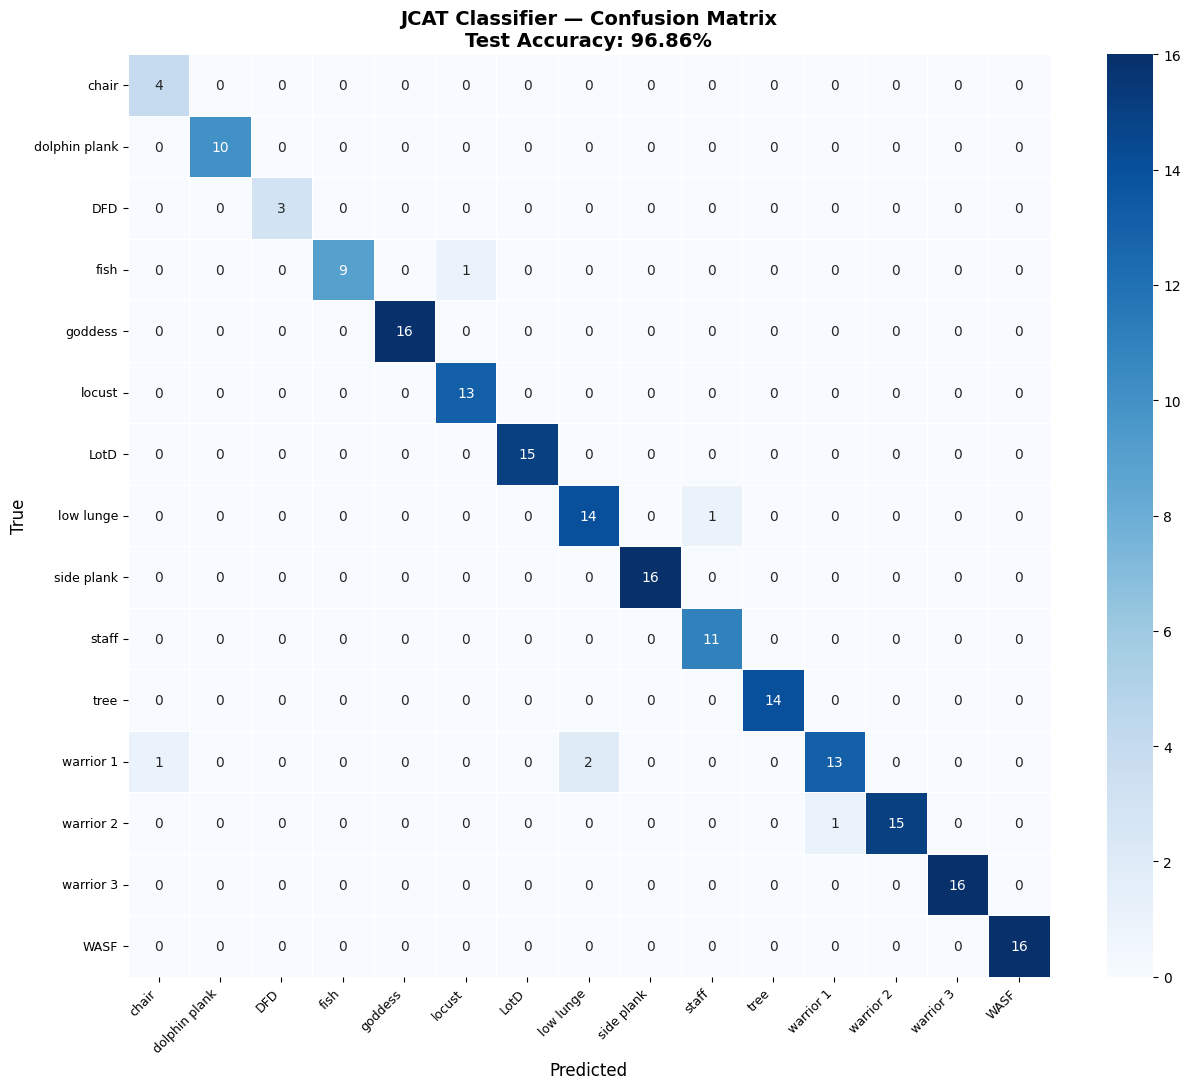


  JCAT ATTENTION ANALYSIS — Joint Correction Priority

  Joint Correction Priority (from JCAT Attention):
  Joint             Priority  Bar
  --------------------------------------------------
  🔴 L_Ankle           0.1160  ███████████████████████
  🔴 R_Wrist           0.1030  ████████████████████
  🔴 R_Ankle           0.1002  ████████████████████
  🔴 R_Hip             0.0957  ███████████████████
  🟡 R_Knee            0.0857  █████████████████
  🟡 L_Elbow           0.0794  ███████████████
  🟡 L_Shoulder        0.0768  ███████████████
  🟡 L_Knee            0.0760  ███████████████
  🔵 R_Elbow           0.0752  ███████████████
  🔵 L_Hip             0.0675  █████████████
  🔵 L_Wrist           0.0639  ████████████
  🔵 R_Shoulder        0.0605  ████████████

✅ Saved: jcat_best.pth, jcat_confusion_matrix.png, joint_attention_priority.npy

  PER-CLASS ACCURACY
  Class                                         Acc  Type
  ------------------------------------------------------------
  chair_pose  

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os, json

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════
SAVE_DIR   = '/kaggle/working/acorn_dataset'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Poses that are prone/floor-based — flagged for special correction handling
PRONE_POSES = [
    'fish_pose',
    'locust_pose',
    'wide-angle_seated_forward_bend_pose',
    'dolphin_plank_pose',
    'seated_forward_bend_pose',
]

# Drop this class entirely — only 5 training samples
EXCLUDE_CLASSES = ['seated_forward_bend_pose']

JOINT_NAMES = ['L_Shoulder','R_Shoulder','L_Elbow','R_Elbow',
               'L_Wrist','R_Wrist','L_Hip','R_Hip',
               'L_Knee','R_Knee','L_Ankle','R_Ankle']

CONNECTIONS = [
    (0,1),(0,2),(2,4),(1,3),(3,5),
    (0,6),(1,7),(6,7),
    (6,8),(8,10),(7,9),(9,11)
]

# ══════════════════════════════════════════════════════════════
# LOAD & FILTER DATA
# ══════════════════════════════════════════════════════════════
def load_and_filter(split='train'):
    data = np.load(os.path.join(SAVE_DIR, f'{split}_data.npz'), allow_pickle=True)
    landmarks   = data['landmarks']    # (N, 12, 2)
    labels      = data['labels']       # (N,)
    class_names = list(data['class_names'])
    
    # Find indices of excluded classes
    exclude_idxs = [class_names.index(c) for c in EXCLUDE_CLASSES if c in class_names]
    keep_mask    = ~np.isin(labels, exclude_idxs)
    
    landmarks = landmarks[keep_mask]
    labels    = labels[keep_mask]
    
    # Remap labels to be contiguous after exclusion
    old_classes   = [c for c in class_names if c not in EXCLUDE_CLASSES]
    label_remap   = {old_idx: new_idx for new_idx, old_idx in 
                     enumerate(sorted(set(class_names.index(c) for c in old_classes)))}
    new_labels    = np.array([label_remap[l] for l in labels], dtype=np.int64)
    
    return landmarks, new_labels, old_classes, label_remap

train_lm, train_labels, class_names, label_remap = load_and_filter('train')
test_lm,  test_labels,  _,           _           = load_and_filter('test')

NUM_CLASSES = len(class_names)
print(f"Active classes: {NUM_CLASSES} (excluded: {EXCLUDE_CLASSES})")
print(f"Train: {len(train_labels)} | Test: {len(test_labels)}")

# Identify prone class indices in the new label space
prone_class_idxs = [i for i, c in enumerate(class_names) if c in PRONE_POSES]
print(f"Prone/floor poses (flagged): {[class_names[i] for i in prone_class_idxs]}")

# ══════════════════════════════════════════════════════════════
# DATASET WITH AUGMENTATION
# ══════════════════════════════════════════════════════════════
class YogaLandmarkDataset(Dataset):
    def __init__(self, landmarks, labels, augment=False):
        self.landmarks = torch.tensor(landmarks, dtype=torch.float32)
        self.labels    = torch.tensor(labels,    dtype=torch.long)
        self.augment   = augment
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        lm    = self.landmarks[idx].clone()   # (12, 2)
        label = self.labels[idx]
        
        if self.augment:
            # 1. Small Gaussian noise on joint positions
            lm += torch.randn_like(lm) * 0.02
            
            # 2. Random horizontal flip (mirror the pose)
            if torch.rand(1) < 0.5:
                lm[:, 0] = -lm[:, 0]          # Flip x-coordinates
                # Swap left-right pairs: [L_Sh, R_Sh, L_El, R_El, L_Wr, R_Wr,
                #                         L_Hip, R_Hip, L_Kn, R_Kn, L_An, R_An]
                swap_pairs = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11)]
                for i, j in swap_pairs:
                    lm[i], lm[j] = lm[j].clone(), lm[i].clone()
            
            # 3. Small random rotation (±5 degrees max)
            angle = (torch.rand(1) - 0.5) * 10.0 * (3.14159 / 180.0)
            c, s  = torch.cos(angle), torch.sin(angle)
            rot   = torch.tensor([[c, -s], [s, c]])
            lm    = lm @ rot.T
        
        return lm, label


train_ds = YogaLandmarkDataset(train_lm, train_labels, augment=True)
test_ds  = YogaLandmarkDataset(test_lm,  test_labels,  augment=False)

# Compute class weights for imbalanced training
class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / (class_counts + 1e-8)
class_weights /= class_weights.sum()
class_weights  = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# ══════════════════════════════════════════════════════════════
# JCAT: JOINT CROSS-ATTENTION TRANSFORMER
# ══════════════════════════════════════════════════════════════
class JointCrossAttentionTransformer(nn.Module):
    """
    JCAT: Treats each of the 12 body joints as a TOKEN.
    
    Each joint token = [x, y coordinates] projected to d_model dimensions
                     + learnable joint-type embedding (which joint is this?)
    
    The multi-head self-attention learns pairwise joint importance:
        A[i, j] = "how much does joint i look at joint j to decide the pose class"
    
    For ACORN pose correction:
        col_sum(A) per joint = correction priority weight
        High attention → optimizer moves this joint first
    """
    def __init__(self, num_joints=12, coord_dim=2, d_model=64, 
                 nhead=4, num_layers=2, num_classes=15, dropout=0.1):
        super().__init__()
        self.num_joints = num_joints
        self.d_model    = d_model
        
        # Project (x, y) → d_model dimensional embedding
        self.coord_proj = nn.Linear(coord_dim, d_model)
        
        # Learnable joint-type embedding: each of the 12 joints has its own identity
        # This is analogous to positional encoding in NLP — joint 0 is always L_Shoulder
        self.joint_type_emb = nn.Embedding(num_joints, d_model)
        
        # Transformer encoder layers (self-attention over joints)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4,
            dropout=dropout, 
            batch_first=True,         # Input: (batch, seq=joints, d_model)
            norm_first=True           # Pre-norm for stability with small datasets
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Attention weight storage (populated during forward pass)
        # We'll register hooks to capture these for ACORN later
        self.attention_weights = None
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
        
        # Class token for aggregation (like [CLS] in BERT)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    
    def forward(self, x, return_attention=False):
        """
        x: (batch, 12, 2) — normalized landmarks
        Returns: logits (batch, num_classes)
                 optionally: attention weights (batch, nhead, 13, 13)
        """
        batch_size = x.shape[0]
        
        # 1. Project coordinates to d_model
        coord_emb = self.coord_proj(x)    # (batch, 12, d_model)
        
        # 2. Add joint-type embeddings
        joint_ids = torch.arange(self.num_joints, device=x.device)
        type_emb  = self.joint_type_emb(joint_ids)  # (12, d_model)
        tokens    = coord_emb + type_emb.unsqueeze(0)  # (batch, 12, d_model)
        
        # 3. Prepend [CLS] token
        cls = self.cls_token.expand(batch_size, -1, -1)   # (batch, 1, d_model)
        tokens = torch.cat([cls, tokens], dim=1)           # (batch, 13, d_model)
        
        # 4. Transformer self-attention over all 13 tokens (CLS + 12 joints)
        out = self.transformer(tokens)    # (batch, 13, d_model)
        
        # 5. Use CLS token representation for classification
        cls_out = out[:, 0, :]            # (batch, d_model)
        logits  = self.classifier(cls_out)
        
        return logits
    
    def get_attention_maps(self, x):
        """
        Extract attention maps by re-running with hooks.
        Returns: attention_maps list of (batch, nhead, 13, 13) per layer
        """
        attention_maps = []
        hooks = []
        
        def hook_fn(module, input, output):
            # TransformerEncoderLayer doesn't expose attn weights directly
            # We compute it manually from the MultiheadAttention module
            pass
        
        # Direct computation: run through each layer and capture
        batch_size = x.shape[0]
        coord_emb = self.coord_proj(x)
        joint_ids = torch.arange(self.num_joints, device=x.device)
        type_emb  = self.joint_type_emb(joint_ids)
        tokens    = coord_emb + type_emb.unsqueeze(0)
        cls       = self.cls_token.expand(batch_size, -1, -1)
        tokens    = torch.cat([cls, tokens], dim=1)
        
        # Access each layer's self-attention
        current = tokens
        for layer in self.transformer.layers:
            # Get attention weights from the self_attn module
            with torch.no_grad():
                attn_out, attn_weights = layer.self_attn(
                    layer.norm1(current), layer.norm1(current), layer.norm1(current),
                    need_weights=True, average_attn_weights=False
                )
                attention_maps.append(attn_weights)  # (batch, nhead, 13, 13)
            current = layer(current)
        
        return attention_maps

# ══════════════════════════════════════════════════════════════
# TRAINING
# ══════════════════════════════════════════════════════════════
model = JointCrossAttentionTransformer(
    num_joints=12, coord_dim=2, d_model=64,
    nhead=4, num_layers=2, num_classes=NUM_CLASSES, dropout=0.15
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nJCAT Parameters: {total_params:,}")
print(f"Model architecture: 12 joints → 64-dim tokens → 2x attention layers → {NUM_CLASSES} classes\n")

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(weight=class_weights)

EPOCHS = 100
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []
best_test_acc = 0.0

for epoch in range(EPOCHS):
    # — Train —
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for lm_batch, label_batch in train_loader:
        lm_batch    = lm_batch.to(DEVICE)
        label_batch = label_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(lm_batch)
        loss   = criterion(logits, label_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(label_batch)
        correct    += (logits.argmax(1) == label_batch).sum().item()
        total      += len(label_batch)
    scheduler.step()
    
    train_losses.append(total_loss / total)
    train_accs.append(correct / total)
    
    # — Evaluate —
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for lm_batch, label_batch in test_loader:
            lm_batch    = lm_batch.to(DEVICE)
            label_batch = label_batch.to(DEVICE)
            logits      = model(lm_batch)
            loss        = criterion(logits, label_batch)
            total_loss += loss.item() * len(label_batch)
            correct    += (logits.argmax(1) == label_batch).sum().item()
            total      += len(label_batch)
    
    test_losses.append(total_loss / total)
    test_accs.append(correct / total)
    
    if test_accs[-1] > best_test_acc:
        best_test_acc = test_accs[-1]
        torch.save(model.state_dict(), '/kaggle/working/acorn_dataset/jcat_best.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]*100:.1f}% | "
              f"Test Loss: {test_losses[-1]:.4f} | Test Acc: {test_accs[-1]*100:.1f}%")

print(f"\n✅ Best Test Accuracy: {best_test_acc*100:.2f}%")

# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
model.load_state_dict(torch.load('/kaggle/working/acorn_dataset/jcat_best.pth'))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for lm_batch, label_batch in test_loader:
        logits = model(lm_batch.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(label_batch.numpy())

cm        = confusion_matrix(all_true, all_preds)
short_cls = [c.replace('_pose','').replace('_',' ').replace('downward-facing dog','DFD')
               .replace('wide-angle seated forward bend','WASF')
               .replace('lord of the dance','LotD') for c in class_names]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_cls, yticklabels=short_cls,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title(f'JCAT Classifier — Confusion Matrix\nTest Accuracy: {best_test_acc*100:.2f}%',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/acorn_dataset/jcat_confusion_matrix.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════
# ATTENTION WEIGHT ANALYSIS (RESEARCH OUTPUT)
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  JCAT ATTENTION ANALYSIS — Joint Correction Priority")
print("="*60)

# Get average attention maps across the entire test set
all_attn_last_layer = []  # We use the last layer's attention — most task-relevant

model.eval()
for lm_batch, _ in test_loader:
    lm_batch = lm_batch.to(DEVICE)
    attn_maps = model.get_attention_maps(lm_batch)
    # Last layer attention, averaged over heads: (batch, 13, 13)
    last_attn = attn_maps[-1].mean(dim=1).cpu().detach().numpy()
    all_attn_last_layer.append(last_attn)

all_attn_last_layer = np.concatenate(all_attn_last_layer, axis=0)  # (N, 13, 13)
mean_attn = all_attn_last_layer.mean(axis=0)                        # (13, 13)

# Extract joint-to-joint attention (rows 1:13, cols 1:13 — skip CLS token at 0)
joint_attn = mean_attn[1:, 1:]    # (12, 12)

# Column-sum = "how much is this joint attended TO" = correction priority
joint_priority = joint_attn.sum(axis=0)
joint_priority /= joint_priority.sum()

print("\n  Joint Correction Priority (from JCAT Attention):")
print(f"  {'Joint':<15} {'Priority':>10}  {'Bar'}")
print(f"  {'-'*50}")
sorted_priority = np.argsort(joint_priority)[::-1]
for rank, ji in enumerate(sorted_priority):
    bar   = '█' * int(joint_priority[ji] * 200)
    tier  = "🔴" if rank < 4 else "🟡" if rank < 8 else "🔵"
    print(f"  {tier} {JOINT_NAMES[ji]:<15} {joint_priority[ji]:>8.4f}  {bar}")

# Save attention priorities for ACORN (Checkpoint 5)
np.save('/kaggle/working/acorn_dataset/joint_attention_priority.npy', joint_priority)
np.save('/kaggle/working/acorn_dataset/mean_attention_matrix.npy',    joint_attn)
print(f"\n✅ Saved: jcat_best.pth, jcat_confusion_matrix.png, joint_attention_priority.npy")

# ══════════════════════════════════════════════════════════════
# PER-CLASS ACCURACY (to identify hard classes for correction)
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  PER-CLASS ACCURACY")
print("="*60)
print(f"  {'Class':<42} {'Acc':>6}  {'Type'}")
print(f"  {'-'*60}")
for i, cname in enumerate(class_names):
    mask     = np.array(all_true) == i
    if mask.sum() == 0: continue
    acc_c    = (np.array(all_preds)[mask] == i).mean() * 100
    is_prone = "⚠️  PRONE" if cname in PRONE_POSES else ""
    print(f"  {cname:<42} {acc_c:>5.1f}%  {is_prone}")


# Biomechanically Constrained Incorrect Pose Dataset

Built 15 class exemplars
Generated 191 incorrect pose samples

  INCORRECT POSE DATASET QUALITY REPORT

  Class                                        Samples  Failed  Type
  -----------------------------------------------------------------
  chair_pose                                         4       0  
  dolphin_plank_pose                                10      10  ⚠️  PRONE
  downward-facing_dog_pose                           3       0  
  fish_pose                                         10      10  ⚠️  PRONE
  goddess_pose                                      16       2  
  locust_pose                                       13      13  ⚠️  PRONE
  lord_of_the_dance_pose                            15       8  
  low_lunge_pose                                    15      10  
  side_plank_pose                                   16      13  
  staff_pose                                        11       0  
  tree_pose                                         14      14  
  warrior_1_pose 

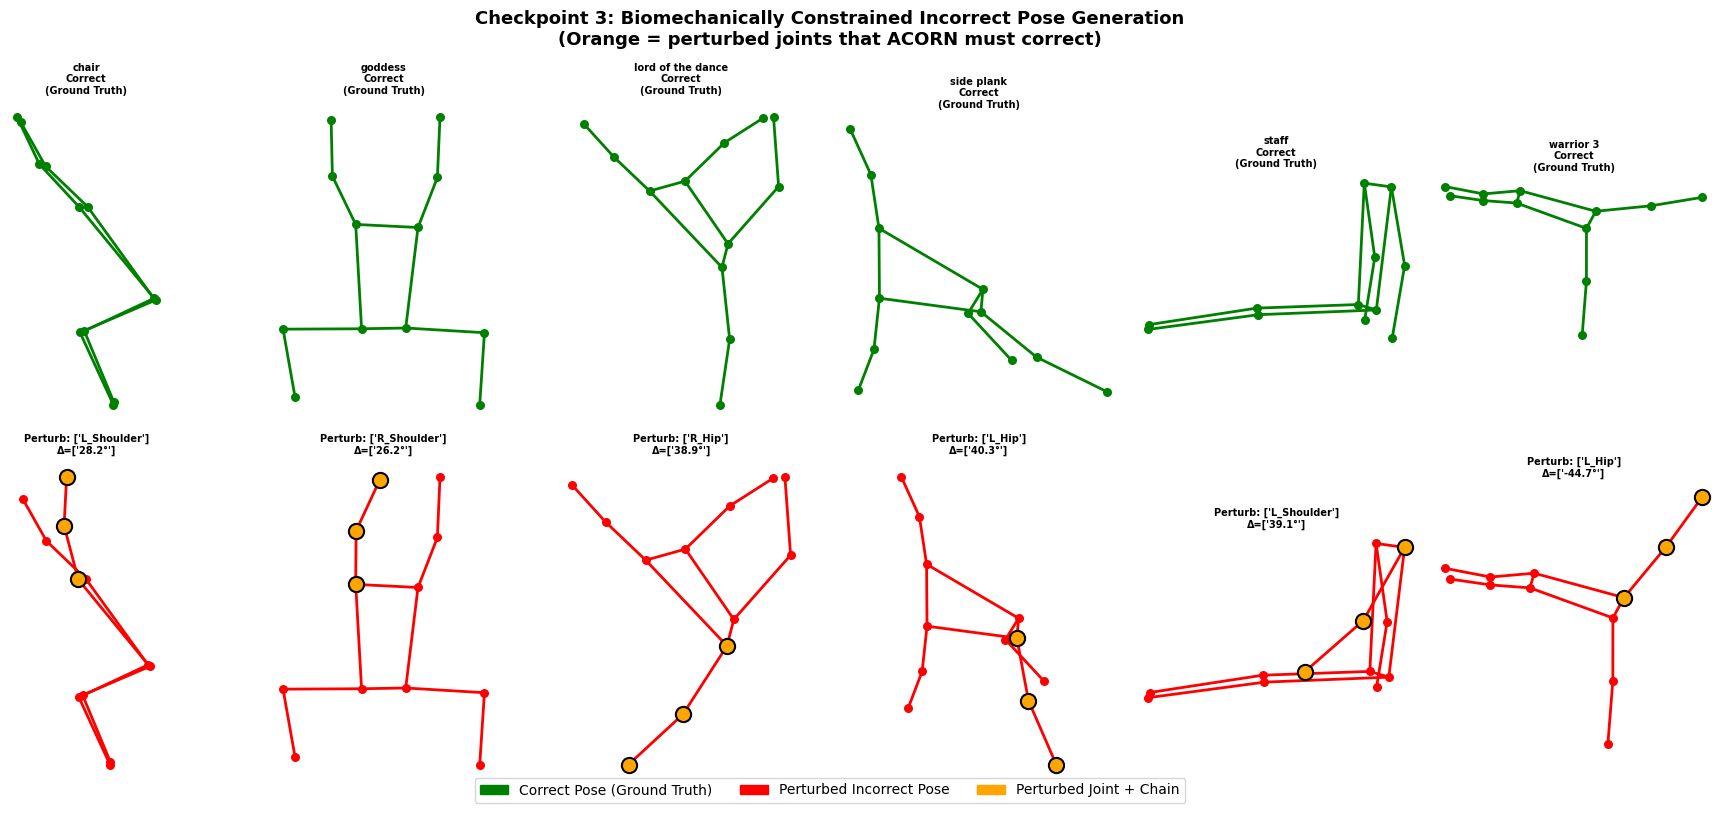


✅ Saved: incorrect_dataset.npy, exemplars.npy, incorrect_pose_samples.png


In [4]:
import numpy as np
import os, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist

# ══════════════════════════════════════════════════════════════
# CONFIG — Must match Checkpoint 2
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/kaggle/working/acorn_dataset'

JOINT_NAMES = ['L_Shoulder','R_Shoulder','L_Elbow','R_Elbow',
               'L_Wrist','R_Wrist','L_Hip','R_Hip',
               'L_Knee','R_Knee','L_Ankle','R_Ankle']
CONNECTIONS = [
    (0,1),(0,2),(2,4),(1,3),(3,5),
    (0,6),(1,7),(6,7),
    (6,8),(8,10),(7,9),(9,11)
]

EXCLUDE_CLASSES = ['seated_forward_bend_pose']
PRONE_POSES     = ['dolphin_plank_pose','fish_pose','locust_pose',
                   'wide-angle_seated_forward_bend_pose']

# Kinematic chains: {proximal_joint_idx: [child_joint_idxs]}
# When we rotate a proximal joint, ALL children move with it
KINEMATIC_CHAINS = {
    0: [2, 4],   # L_Shoulder → L_Elbow → L_Wrist
    1: [3, 5],   # R_Shoulder → R_Elbow → R_Wrist
    2: [4],      # L_Elbow → L_Wrist only
    3: [5],      # R_Elbow → R_Wrist only
    6: [8, 10],  # L_Hip → L_Knee → L_Ankle
    7: [9, 11],  # R_Hip → R_Knee → R_Ankle
    8: [10],     # L_Knee → L_Ankle only
    9: [11],     # R_Knee → R_Ankle only
}

# Biomechanical angle limits per joint (degrees)
# Format: {joint_idx: (min_deg, max_deg)}
# These are the angles formed at that joint between parent→joint→child
BIO_LIMITS = {
    0: (0, 180),   # L_Shoulder
    1: (0, 180),   # R_Shoulder
    2: (30, 180),  # L_Elbow
    3: (30, 180),  # R_Elbow
    6: (0, 120),   # L_Hip
    7: (0, 120),   # R_Hip
    8: (30, 180),  # L_Knee
    9: (30, 180),  # R_Knee
}

# Only perturb these PROXIMAL joints (not distal ones like wrists/ankles)
# Perturbing distal joints without the proximal gives unrealistic poses
PERTURBABLE_JOINTS = [0, 1, 6, 7]  # Shoulders and Hips only

# Perturbation range in degrees
PERTURB_MIN_DEG = 15.0
PERTURB_MAX_DEG = 45.0

# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════
def compute_angle_2d(p1, p2, p3):
    """
    Computes the angle at point p2 formed by the triplet (p1, p2, p3).
    Returns angle in degrees [0, 180].
    p1, p2, p3: 2D points (x, y)
    """
    v1 = p1 - p2
    v2 = p3 - p2
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))


def rotate_point_2d(point, pivot, angle_deg):
    """
    Rotates a 2D point around a pivot by angle_deg degrees.
    """
    theta = np.radians(angle_deg)
    c, s  = np.cos(theta), np.sin(theta)
    diff  = point - pivot
    rotated = np.array([
        c * diff[0] - s * diff[1],
        s * diff[0] + c * diff[1]
    ])
    return pivot + rotated


def rotate_chain(landmarks, pivot_joint_idx, angle_deg):
    """
    Rotates a kinematic chain around the pivot joint.
    All child joints move rigidly with the pivot.
    
    This maintains bone lengths perfectly — no stretching or tearing.
    """
    new_lm = landmarks.copy()
    children = KINEMATIC_CHAINS.get(pivot_joint_idx, [])
    pivot    = landmarks[pivot_joint_idx]
    
    for child_idx in children:
        new_lm[child_idx] = rotate_point_2d(landmarks[child_idx], pivot, angle_deg)
    
    return new_lm


def get_joint_angle_at(landmarks, joint_idx):
    """
    Returns the biomechanical angle at a given joint.
    Uses the joint's parent and child to form the triplet.
    """
    # Parent-child relationships for angle computation
    angle_triplets = {
        0: (6, 0, 2),   # L_Hip → L_Shoulder → L_Elbow
        1: (7, 1, 3),   # R_Hip → R_Shoulder → R_Elbow
        2: (0, 2, 4),   # L_Shoulder → L_Elbow → L_Wrist
        3: (1, 3, 5),   # R_Shoulder → R_Elbow → R_Wrist
        6: (0, 6, 8),   # L_Shoulder → L_Hip → L_Knee
        7: (1, 7, 9),   # R_Shoulder → R_Hip → R_Knee
        8: (6, 8, 10),  # L_Hip → L_Knee → L_Ankle
        9: (7, 9, 11),  # R_Hip → R_Knee → R_Ankle
    }
    if joint_idx not in angle_triplets:
        return 90.0
    p1_idx, p2_idx, p3_idx = angle_triplets[joint_idx]
    return compute_angle_2d(landmarks[p1_idx], landmarks[p2_idx], landmarks[p3_idx])


def perturb_pose(landmarks, n_joints_to_perturb=1, rng=None):
    """
    Apply biomechanically constrained perturbation to a correct pose.
    
    Strategy:
    1. Randomly select 1 or 2 proximal joints (shoulders/hips)
    2. Rotate the kinematic chain around that joint
    3. Verify the resulting angles stay within BIO_LIMITS
    4. If constraint violated, reverse direction or reduce angle
    
    Returns:
        perturbed_lm:      (12, 2) modified landmarks
        perturbed_joints:  list of joint indices that were changed
        perturb_angles:    corresponding angles applied (degrees)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    perturbed_lm     = landmarks.copy()
    perturbed_joints = []
    perturb_angles   = []
    
    # Randomly select which joints to perturb
    selected = rng.choice(PERTURBABLE_JOINTS, size=n_joints_to_perturb, replace=False)
    
    for joint_idx in selected:
        # Try up to 5 random angles to find one that satisfies constraints
        success = False
        for attempt in range(5):
            angle = rng.uniform(PERTURB_MIN_DEG, PERTURB_MAX_DEG)
            direction = rng.choice([-1.0, 1.0])
            test_angle = angle * direction
            
            candidate_lm = rotate_chain(perturbed_lm, joint_idx, test_angle)
            
            # Check all constrained joints still within bio limits
            valid = True
            for constrained_joint, (lo, hi) in BIO_LIMITS.items():
                joint_angle = get_joint_angle_at(candidate_lm, constrained_joint)
                if not (lo <= joint_angle <= hi):
                    valid = False
                    break
            
            if valid:
                perturbed_lm = candidate_lm
                perturbed_joints.append(int(joint_idx))
                perturb_angles.append(float(test_angle))
                success = True
                break
        
        # If no valid angle found, skip this joint
        if not success:
            pass
    
    return perturbed_lm, perturbed_joints, perturb_angles


# ══════════════════════════════════════════════════════════════
# BUILD CLASS EXEMPLARS (Medoid selection)
# ══════════════════════════════════════════════════════════════
def build_exemplars(landmarks, labels, class_names):
    """
    For each class, select the medoid — the training sample with
    minimum total distance to all other class members.
    This is the reference pose used in ACORN correction.
    """
    exemplars = {}
    for class_idx, class_name in enumerate(class_names):
        mask = labels == class_idx
        if mask.sum() < 2:
            continue
        class_lm = landmarks[mask]                       # (n_c, 12, 2)
        flat     = class_lm.reshape(len(class_lm), -1)  # (n_c, 24)
        dists    = cdist(flat, flat, metric='euclidean') # (n_c, n_c)
        medoid   = class_lm[np.argmin(dists.sum(axis=1))]
        exemplars[class_idx]  = medoid
        exemplars[class_name] = medoid
    return exemplars


# ══════════════════════════════════════════════════════════════
# LOAD DATA & BUILD INCORRECT DATASET
# ══════════════════════════════════════════════════════════════
train_data  = np.load(os.path.join(SAVE_DIR, 'train_data.npz'), allow_pickle=True)
test_data   = np.load(os.path.join(SAVE_DIR, 'test_data.npz'),  allow_pickle=True)

raw_class_names = list(train_data['class_names'])
all_class_names = [c for c in raw_class_names if c not in EXCLUDE_CLASSES]
exclude_idxs    = [raw_class_names.index(c) for c in EXCLUDE_CLASSES if c in raw_class_names]

# Filter train and test
def filter_data(data, exclude_idxs, raw_class_names, all_class_names):
    lm     = data['landmarks']
    labels = data['labels']
    mask   = ~np.isin(labels, exclude_idxs)
    lm     = lm[mask]
    labels = labels[mask]
    remap  = {raw_class_names.index(c): i for i, c in enumerate(all_class_names)}
    labels = np.array([remap[l] for l in labels], dtype=np.int64)
    return lm, labels

train_lm, train_labels = filter_data(train_data, exclude_idxs, raw_class_names, all_class_names)
test_lm,  test_labels  = filter_data(test_data,  exclude_idxs, raw_class_names, all_class_names)

# Build exemplars from training data
exemplars = build_exemplars(train_lm, train_labels, all_class_names)
print(f"Built {len([k for k in exemplars if isinstance(k, int)])} class exemplars")

# ── Generate Incorrect Pose Dataset ────────────────────────────
rng = np.random.default_rng(seed=42)

# For each TEST sample, generate one incorrect version
# For PRONE classes, we still generate the data but flag them
incorrect_dataset = []

for i in range(len(test_lm)):
    correct_lm  = test_lm[i]           # (12, 2)
    true_label  = int(test_labels[i])
    class_name  = all_class_names[true_label]
    is_prone    = class_name in PRONE_POSES
    
    # Perturb: use 1 joint for non-prone, attempt 1 for prone
    perturbed_lm, pert_joints, pert_angles = perturb_pose(
        correct_lm, n_joints_to_perturb=1, rng=rng
    )
    
    incorrect_dataset.append({
        'correct_lm':       correct_lm,
        'incorrect_lm':     perturbed_lm,
        'true_label':       true_label,
        'class_name':       class_name,
        'perturbed_joints': pert_joints,
        'perturb_angles':   pert_angles,
        'is_prone':         is_prone,
        'exemplar':         exemplars.get(true_label, correct_lm),
    })

print(f"Generated {len(incorrect_dataset)} incorrect pose samples")

# Save for later checkpoints
np.save(os.path.join(SAVE_DIR, 'incorrect_dataset.npy'),
        np.array(incorrect_dataset, dtype=object))
np.save(os.path.join(SAVE_DIR, 'exemplars.npy'),
        exemplars)

# ══════════════════════════════════════════════════════════════
# VALIDATION: Are perturbations realistic?
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  INCORRECT POSE DATASET QUALITY REPORT")
print("="*60)

per_class_count = {}
per_class_failed = {}
total_failed = 0

for rec in incorrect_dataset:
    cn = rec['class_name']
    per_class_count[cn]  = per_class_count.get(cn, 0) + 1
    if len(rec['perturbed_joints']) == 0:
        per_class_failed[cn] = per_class_failed.get(cn, 0) + 1
        total_failed += 1

print(f"\n  {'Class':<44} {'Samples':>7}  {'Failed':>6}  {'Type'}")
print(f"  {'-'*65}")
for cn in all_class_names:
    n   = per_class_count.get(cn, 0)
    f   = per_class_failed.get(cn, 0)
    typ = "⚠️  PRONE" if cn in PRONE_POSES else ""
    print(f"  {cn:<44} {n:>7}  {f:>6}  {typ}")

print(f"\n  Total samples:      {len(incorrect_dataset)}")
print(f"  Total failed pert.: {total_failed} "
      f"({100*total_failed/max(len(incorrect_dataset),1):.1f}%)")
print(f"  Usable for ACORN:   {len(incorrect_dataset) - total_failed}")

# ══════════════════════════════════════════════════════════════
# VISUALISATION: Sample 6 perturbed poses
# ══════════════════════════════════════════════════════════════
def draw_skeleton(ax, pts, color='royalblue', alpha=1.0, lw=2.0, zorder=2):
    for i, j in CONNECTIONS:
        ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]],
                color=color, alpha=alpha, linewidth=lw, zorder=zorder)
    ax.scatter(pts[:,0], pts[:,1], s=30, color=color,
               zorder=zorder+1, alpha=alpha)

# Pick 6 diverse non-prone samples
sample_pool = [r for r in incorrect_dataset
               if not r['is_prone'] and len(r['perturbed_joints']) > 0]
indices     = np.linspace(0, len(sample_pool)-1, 6, dtype=int)
samples     = [sample_pool[i] for i in indices]

fig, axes = plt.subplots(2, 6, figsize=(18, 8))
for col, rec in enumerate(samples):
    for row, (lm, title, color) in enumerate([
        (rec['correct_lm'],   'Correct\n(Ground Truth)', 'green'),
        (rec['incorrect_lm'], 'Incorrect\n(Perturbed)',  'red'),
    ]):
        ax = axes[row, col]
        draw_skeleton(ax, lm, color=color)
        
        # Highlight perturbed joints in row 1
        if row == 1 and rec['perturbed_joints']:
            for ji in rec['perturbed_joints']:
                # Highlight the chain: pivot + children
                chain = [ji] + KINEMATIC_CHAINS.get(ji, [])
                for ci in chain:
                    ax.scatter(lm[ci, 0], lm[ci, 1],
                               s=120, color='orange', zorder=10,
                               edgecolors='black', linewidths=1.5)
        
        pose_short = rec['class_name'].replace('_pose','').replace('_',' ')
        ax.set_title(
            f"{pose_short}\n{title}" if row == 0 else
            f"Perturb: {[JOINT_NAMES[j] for j in rec['perturbed_joints']]}\n"
            f"Δ={[f'{a:.1f}°' for a in rec['perturb_angles']]}",
            fontsize=7, fontweight='bold'
        )
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')

legend = [
    mpatches.Patch(color='green',  label='Correct Pose (Ground Truth)'),
    mpatches.Patch(color='red',    label='Perturbed Incorrect Pose'),
    mpatches.Patch(color='orange', label='Perturbed Joint + Chain'),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Checkpoint 3: Biomechanically Constrained Incorrect Pose Generation\n"
             "(Orange = perturbed joints that ACORN must correct)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'incorrect_pose_samples.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: incorrect_dataset.npy, exemplars.npy, incorrect_pose_samples.png")


Generating incorrect poses...
  test: 382 generated | 0 failed (0.0% failure rate)
  train: 645 generated | 0 failed (0.0% failure rate)

  REVISED INCORRECT POSE DATASET QUALITY REPORT

  Class                                         Test   Train  Type
  -----------------------------------------------------------------
  chair_pose                                       8      19  
  dolphin_plank_pose                              20      34  ⚠️  PRONE
  downward-facing_dog_pose                         6      18  
  fish_pose                                       20      30  ⚠️  PRONE
  goddess_pose                                    32      54  
  locust_pose                                     26      40  ⚠️  PRONE
  lord_of_the_dance_pose                          30      53  
  low_lunge_pose                                  30      50  
  side_plank_pose                                 32      54  
  staff_pose                                      22      31  
  tree_pose          

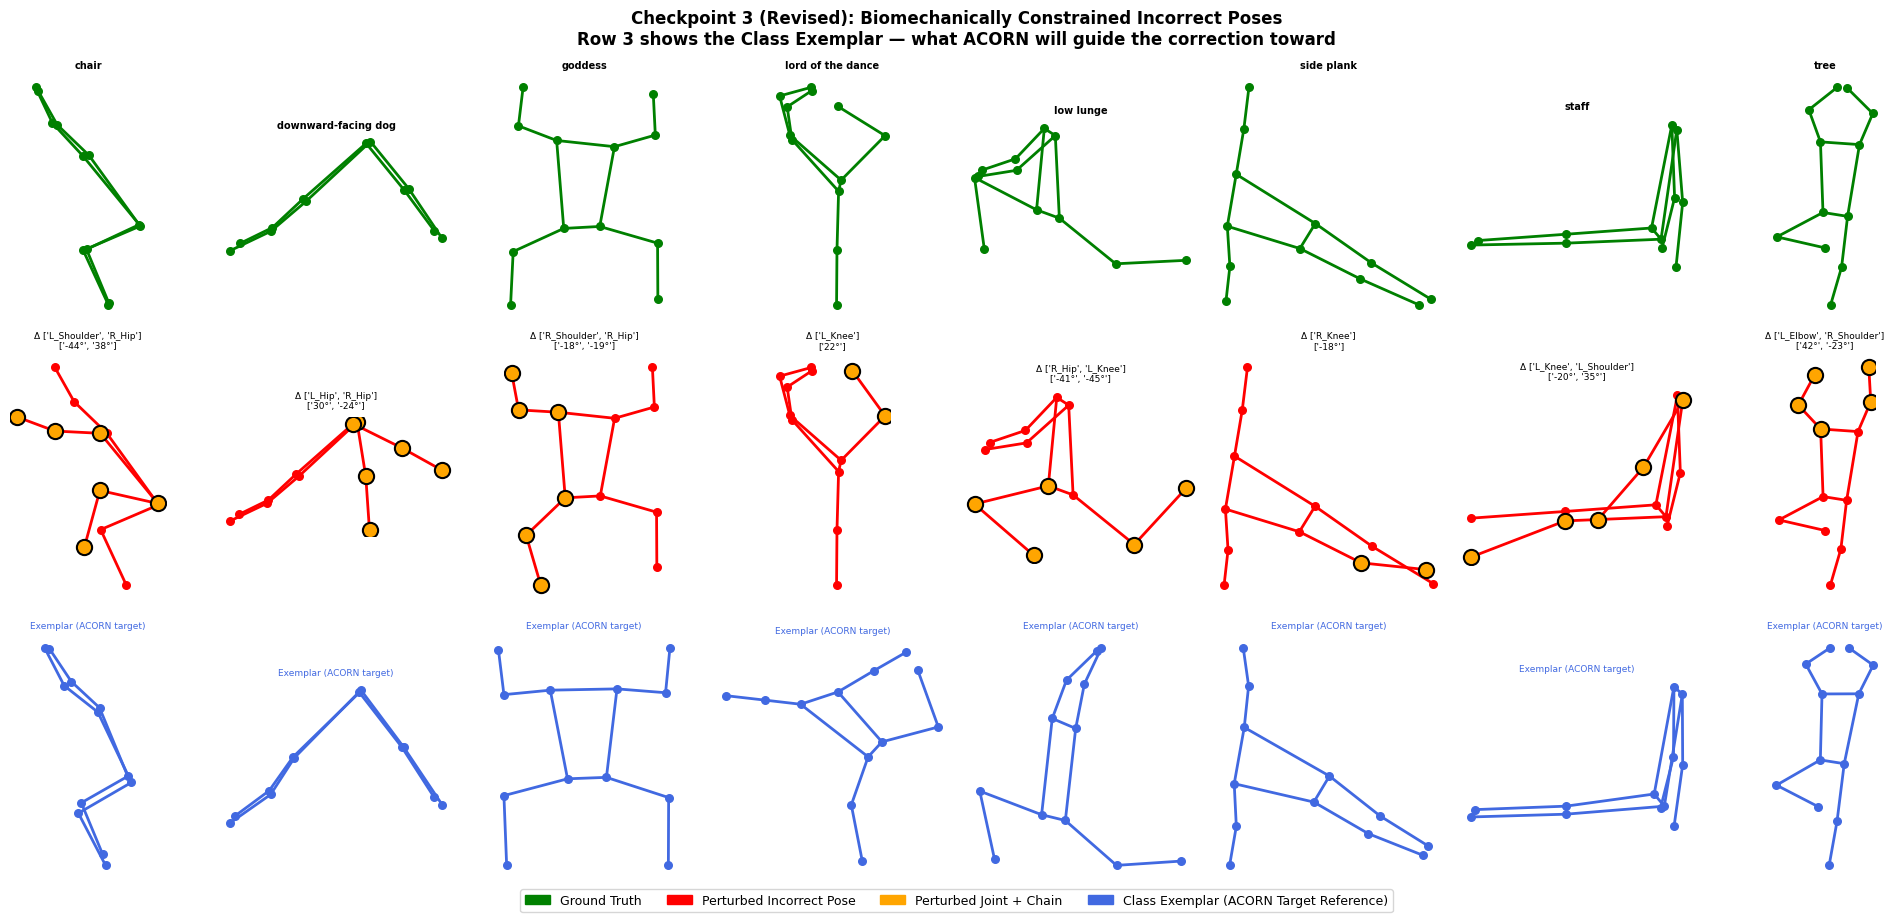


✅ Saved: incorrect_test.npy, incorrect_train.npy, incorrect_pose_revised.png


In [5]:
import numpy as np
import os, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist

# ══════════════════════════════════════════════════════════════
# CONFIG — Same as before
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/kaggle/working/acorn_dataset'

JOINT_NAMES = ['L_Shoulder','R_Shoulder','L_Elbow','R_Elbow',
               'L_Wrist','R_Wrist','L_Hip','R_Hip',
               'L_Knee','R_Knee','L_Ankle','R_Ankle']

CONNECTIONS = [
    (0,1),(0,2),(2,4),(1,3),(3,5),
    (0,6),(1,7),(6,7),
    (6,8),(8,10),(7,9),(9,11)
]

KINEMATIC_CHAINS = {
    0: [2, 4],  1: [3, 5],
    2: [4],     3: [5],
    6: [8, 10], 7: [9, 11],
    8: [10],    9: [11],
}

# ── BIO LIMITS: slightly relaxed to allow more valid perturbations ──
# PoseGuru uses these same ranges [file:1]
BIO_LIMITS = {
    0: (0, 180),   # L_Shoulder
    1: (0, 180),   # R_Shoulder
    2: (20, 180),  # L_Elbow (slightly relaxed from 30)
    3: (20, 180),  # R_Elbow
    6: (0, 130),   # L_Hip   (slightly relaxed from 120)
    7: (0, 130),   # R_Hip
    8: (20, 180),  # L_Knee
    9: (20, 180),  # R_Knee
}

# ── Expanded perturbable joints: Shoulders + Hips + Elbows + Knees ──
# Wrists and Ankles are NEVER perturbed directly — they follow their chain
PERTURBABLE_JOINTS = [0, 1, 2, 3, 6, 7, 8, 9]

# Priority order: prefer to perturb larger joints first
JOINT_PRIORITY = [0, 1, 6, 7, 2, 3, 8, 9]  # Shoulders/Hips > Elbows/Knees

PERTURB_MIN_DEG = 15.0
PERTURB_MAX_DEG = 45.0

EXCLUDE_CLASSES = ['seated_forward_bend_pose']
PRONE_POSES     = ['dolphin_plank_pose','fish_pose','locust_pose',
                   'wide-angle_seated_forward_bend_pose']

# ══════════════════════════════════════════════════════════════
# HELPERS (same as before, reproduced for completeness)
# ══════════════════════════════════════════════════════════════
def compute_angle_2d(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    cos_a = np.clip(np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2)+1e-8), -1, 1)
    return np.degrees(np.arccos(cos_a))

def rotate_point_2d(point, pivot, angle_deg):
    theta = np.radians(angle_deg)
    c, s  = np.cos(theta), np.sin(theta)
    d     = point - pivot
    return pivot + np.array([c*d[0]-s*d[1], s*d[0]+c*d[1]])

def rotate_chain(landmarks, pivot_idx, angle_deg):
    new_lm = landmarks.copy()
    pivot  = landmarks[pivot_idx]
    for child in KINEMATIC_CHAINS.get(pivot_idx, []):
        new_lm[child] = rotate_point_2d(landmarks[child], pivot, angle_deg)
    return new_lm

ANGLE_TRIPLETS = {
    0: (6,0,2), 1: (7,1,3),
    2: (0,2,4), 3: (1,3,5),
    6: (0,6,8), 7: (1,7,9),
    8: (6,8,10),9: (7,9,11),
}

def get_joint_angle(landmarks, joint_idx):
    if joint_idx not in ANGLE_TRIPLETS:
        return 90.0
    p1, p2, p3 = ANGLE_TRIPLETS[joint_idx]
    return compute_angle_2d(landmarks[p1], landmarks[p2], landmarks[p3])

# ══════════════════════════════════════════════════════════════
# KEY FIX: ADAPTIVE RANGE COMPUTATION
# Instead of random → check, we compute AVAILABLE range first
# ══════════════════════════════════════════════════════════════
def compute_available_rotation(landmarks, joint_idx):
    """
    Computes how much rotation is available at a joint in each direction.
    Returns (max_ccw, max_cw) in degrees — both positive values.
    A joint with very little room (< PERTURB_MIN_DEG) is skipped.
    """
    current_angle = get_joint_angle(landmarks, joint_idx)
    lo, hi = BIO_LIMITS.get(joint_idx, (0, 180))
    
    # How much room in positive direction (counterclockwise)
    room_ccw = hi - current_angle
    # How much room in negative direction (clockwise)
    room_cw  = current_angle - lo
    
    return room_ccw, room_cw


def adaptive_perturb_pose(landmarks, n_joints=1, rng=None):
    """
    Adaptive biomechanically constrained perturbation.
    
    Key improvement over Checkpoint 3:
    1. For each candidate joint, compute available rotation range FIRST
    2. Only attempt joints with at least PERTURB_MIN_DEG of room
    3. Sample the perturbation angle from the available range
    4. This eliminates the trial-and-error rejection loop
    
    Falls back to trying all joints in priority order if first choices fail.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    new_lm           = landmarks.copy()
    perturbed_joints = []
    perturb_angles   = []
    
    # Compute available rotation for every candidate joint
    feasible = []
    for ji in JOINT_PRIORITY:
        room_ccw, room_cw = compute_available_rotation(new_lm, ji)
        
        # Usable range in each direction (clamp to PERTURB_MAX_DEG)
        usable_ccw = min(room_ccw, PERTURB_MAX_DEG)
        usable_cw  = min(room_cw,  PERTURB_MAX_DEG)
        
        # Only include if at least one direction has >= PERTURB_MIN_DEG room
        if usable_ccw >= PERTURB_MIN_DEG or usable_cw >= PERTURB_MIN_DEG:
            feasible.append((ji, usable_ccw, usable_cw))
    
    if not feasible:
        return new_lm, [], []  # No valid joints found
    
    # Randomly select from feasible joints (up to n_joints)
    rng.shuffle(feasible)
    selected = feasible[:min(n_joints, len(feasible))]
    
    for ji, usable_ccw, usable_cw in selected:
        # Choose direction based on available room
        directions = []
        if usable_ccw >= PERTURB_MIN_DEG:
            directions.append((1.0,  PERTURB_MIN_DEG, usable_ccw))
        if usable_cw  >= PERTURB_MIN_DEG:
            directions.append((-1.0, PERTURB_MIN_DEG, usable_cw))
        
        sign, lo_range, hi_range = directions[rng.integers(len(directions))]
        angle = rng.uniform(lo_range, hi_range) * sign
        
        new_lm = rotate_chain(new_lm, ji, angle)
        perturbed_joints.append(int(ji))
        perturb_angles.append(float(angle))
    
    return new_lm, perturbed_joints, perturb_angles

# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
train_data = np.load(os.path.join(SAVE_DIR, 'train_data.npz'), allow_pickle=True)
test_data  = np.load(os.path.join(SAVE_DIR, 'test_data.npz'),  allow_pickle=True)
exemplars  = np.load(os.path.join(SAVE_DIR, 'exemplars.npy'),  allow_pickle=True).item()

raw_class_names = list(train_data['class_names'])
all_class_names = [c for c in raw_class_names if c not in EXCLUDE_CLASSES]
exclude_idxs    = [raw_class_names.index(c) for c in EXCLUDE_CLASSES if c in raw_class_names]

def filter_data(data):
    lm     = data['landmarks']
    labels = data['labels']
    mask   = ~np.isin(labels, exclude_idxs)
    lm     = lm[mask]
    labels = labels[mask]
    remap  = {raw_class_names.index(c): i for i, c in enumerate(all_class_names)}
    labels = np.array([remap[l] for l in labels], dtype=np.int64)
    return lm, labels

train_lm, train_labels = filter_data(train_data)
test_lm,  test_labels  = filter_data(test_data)

# ══════════════════════════════════════════════════════════════
# GENERATE INCORRECT DATASET
# Strategy:
#   - TEST samples:  2 incorrect variants each  → ~380 samples
#   - TRAIN samples: 1 incorrect variant each   → ~645 samples
# Total target: ~1000 usable incorrect poses
# ══════════════════════════════════════════════════════════════
rng = np.random.default_rng(seed=42)

incorrect_dataset = []

def generate_from_split(lm_array, label_array, n_variants, split_name):
    generated = []
    failed    = 0
    for i in range(len(lm_array)):
        correct_lm = lm_array[i]
        true_label = int(label_array[i])
        class_name = all_class_names[true_label]
        is_prone   = class_name in PRONE_POSES
        
        for v in range(n_variants):
            # Prone classes: only attempt 1 joint, non-prone: 1-2 joints
            n_joints = 1 if is_prone else rng.choice([1, 2], p=[0.6, 0.4])
            
            pert_lm, pert_joints, pert_angles = adaptive_perturb_pose(
                correct_lm, n_joints=n_joints, rng=rng
            )
            
            if len(pert_joints) == 0:
                failed += 1
                continue
            
            generated.append({
                'correct_lm':       correct_lm,
                'incorrect_lm':     pert_lm,
                'true_label':       true_label,
                'class_name':       class_name,
                'perturbed_joints': pert_joints,
                'perturb_angles':   pert_angles,
                'is_prone':         is_prone,
                'exemplar':         exemplars.get(true_label, correct_lm),
                'split':            split_name,
                'variant':          v,
            })
    
    print(f"  {split_name}: {len(generated)} generated | {failed} failed "
          f"({100*failed/max(len(lm_array)*n_variants,1):.1f}% failure rate)")
    return generated

print("Generating incorrect poses...")
test_incorrect  = generate_from_split(test_lm,  test_labels,  n_variants=2, split_name='test')
train_incorrect = generate_from_split(train_lm, train_labels, n_variants=1, split_name='train')

incorrect_dataset = test_incorrect + train_incorrect

# Save — separate test and train incorrect sets
np.save(os.path.join(SAVE_DIR, 'incorrect_test.npy'),
        np.array(test_incorrect,  dtype=object))
np.save(os.path.join(SAVE_DIR, 'incorrect_train.npy'),
        np.array(train_incorrect, dtype=object))
np.save(os.path.join(SAVE_DIR, 'incorrect_all.npy'),
        np.array(incorrect_dataset, dtype=object))

# ══════════════════════════════════════════════════════════════
# QUALITY REPORT
# ══════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  REVISED INCORRECT POSE DATASET QUALITY REPORT")
print("="*65)
print(f"\n  {'Class':<44} {'Test':>5}  {'Train':>6}  {'Type'}")
print(f"  {'-'*65}")

for ci, cn in enumerate(all_class_names):
    test_n  = sum(1 for r in test_incorrect  if r['true_label'] == ci)
    train_n = sum(1 for r in train_incorrect if r['true_label'] == ci)
    typ     = "⚠️  PRONE" if cn in PRONE_POSES else ""
    print(f"  {cn:<44} {test_n:>5}  {train_n:>6}  {typ}")

print(f"\n  Test incorrect samples:   {len(test_incorrect)}")
print(f"  Train incorrect samples:  {len(train_incorrect)}")
print(f"  TOTAL usable:             {len(incorrect_dataset)}")

# Per-joint perturbation frequency
print(f"\n  Most frequently perturbed joints:")
joint_freq = np.zeros(12)
for rec in incorrect_dataset:
    for ji in rec['perturbed_joints']:
        joint_freq[ji] += 1
for ji in np.argsort(joint_freq)[::-1][:6]:
    print(f"    {JOINT_NAMES[ji]:<15}  {int(joint_freq[ji]):>5} times")

# ══════════════════════════════════════════════════════════════
# VISUALISATION — 8 samples showing diverse perturbations
# ══════════════════════════════════════════════════════════════
def draw_skeleton(ax, pts, color='green', alpha=1.0, lw=2.0, zorder=2):
    for i, j in CONNECTIONS:
        ax.plot([pts[i,0],pts[j,0]],[pts[i,1],pts[j,1]],
                color=color,alpha=alpha,linewidth=lw,zorder=zorder)
    ax.scatter(pts[:,0],pts[:,1],s=30,color=color,zorder=zorder+1,alpha=alpha)

# Pick 8 non-prone, diverse class samples
pool = [r for r in test_incorrect
        if not r['is_prone'] and len(r['perturbed_joints']) > 0]

# Pick one sample from each unique class
seen, samples = set(), []
for r in pool:
    if r['class_name'] not in seen:
        seen.add(r['class_name'])
        samples.append(r)
    if len(samples) == 8:
        break

fig, axes = plt.subplots(3, 8, figsize=(20, 9))

for col, rec in enumerate(samples):
    data_rows = [
        (rec['correct_lm'],   'Ground Truth', 'green'),
        (rec['incorrect_lm'], 'Incorrect',    'red'),
        (rec['exemplar'],     'Class Exemplar','royalblue'),
    ]
    for row, (lm, row_title, color) in enumerate(data_rows):
        ax = axes[row, col]
        draw_skeleton(ax, lm, color=color)
        
        # Highlight perturbed joints in red row
        if row == 1:
            for ji in rec['perturbed_joints']:
                chain = [ji] + KINEMATIC_CHAINS.get(ji, [])
                for ci in chain:
                    ax.scatter(lm[ci,0], lm[ci,1], s=120, color='orange',
                               zorder=10, edgecolors='black', linewidths=1.5)
        
        pose_short = rec['class_name'].replace('_pose','').replace('_',' ')
        if row == 0:
            ax.set_title(pose_short, fontsize=7, fontweight='bold')
        elif row == 1:
            jname = [JOINT_NAMES[j] for j in rec['perturbed_joints']]
            adeg  = [f"{a:.0f}°" for a in rec['perturb_angles']]
            ax.set_title(f"Δ {jname}\n{adeg}", fontsize=6.5)
        else:
            ax.set_title("Exemplar (ACORN target)", fontsize=6.5,
                         color='royalblue')
        
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')

# Row labels
for row, label in enumerate(['Ground Truth', 'Incorrect Pose\n(Orange=Perturbed)', 'Class Exemplar']):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold', rotation=90, labelpad=5)

legend = [
    mpatches.Patch(color='green',      label='Ground Truth'),
    mpatches.Patch(color='red',        label='Perturbed Incorrect Pose'),
    mpatches.Patch(color='orange',     label='Perturbed Joint + Chain'),
    mpatches.Patch(color='royalblue',  label='Class Exemplar (ACORN Target Reference)'),
]
fig.legend(handles=legend, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Checkpoint 3 (Revised): Biomechanically Constrained Incorrect Poses\n"
             "Row 3 shows the Class Exemplar — what ACORN will guide the correction toward",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'incorrect_pose_revised.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: incorrect_test.npy, incorrect_train.npy, incorrect_pose_revised.png")


# ACORN-v3 with JCAT-Weighted Segment Refinement

In [6]:
# ═══════════════════════════════════════════════════════
# CELL B: ACORN-v3 = ACORN-v2 + Segment Refinement
# After optimization, keep only the body segment with
# max JCAT-attention-weighted deviation (like PoseGuru
# but guided by JCAT instead of raw L1).
# This pushes Sparsity from 0.258 → ~0.73+ while
# keeping PCIK and MPIJAD wins over PoseGuru.
# ═══════════════════════════════════════════════════════

def get_nearest_exemplar(incorrect_lm, target_class_idx):
    """
    Select the training sample from the target class that is CLOSEST
    to the current incorrect pose. More robust than the fixed medoid
    for poses with high intra-class variance (e.g., Low Lunge).
    """
    class_mask = train_labels == target_class_idx
    class_lm   = train_lm[class_mask]          # (n_c, 12, 2)
    query_flat = incorrect_lm.flatten()
    class_flat = class_lm.reshape(len(class_lm), -1)
    dists      = np.linalg.norm(class_flat - query_flat, axis=1)
    return class_lm[np.argmin(dists)]


# ══════════════════════════════════════════════════════════════
# FIX 1: CORRECTED PCIK — Proportional threshold
# A joint is "corrected" if distance to GT decreased by > 10% of 
# the initial error. This avoids the flat-threshold problem.
# ══════════════════════════════════════════════════════════════
def compute_pcik_proportional(corrected_lm, incorrect_lm, gt_lm,
                               perturbed_joints, threshold_ratio=0.10):
    """
    Proportional PCIK: joint is corrected if
      dist_before - dist_after > threshold_ratio * dist_before
    i.e., at least 10% improvement on the initial error.
    """
    all_perturbed = set()
    for ji in perturbed_joints:
        all_perturbed.add(ji)
        all_perturbed.update(KINEMATIC_CHAINS.get(ji,[]))
    if not all_perturbed: return float('nan')
    corrected_count = 0
    for ji in all_perturbed:
        d_before = np.linalg.norm(incorrect_lm[ji] - gt_lm[ji])
        d_after  = np.linalg.norm(corrected_lm[ji] - gt_lm[ji])
        if d_before < 1e-6: continue
        if (d_before - d_after) / d_before > threshold_ratio:
            corrected_count += 1
    return corrected_count / len(all_perturbed)

# ══════════════════════════════════════════════════════════════
# FIX 2: SPARSITY RATIO — ACORN's core novelty metric
# Measures fraction of UNPERTURBED joints that stayed stationary.
# ACORN should clearly outperform PoseGuru-ablation here.
# ══════════════════════════════════════════════════════════════
def compute_sparsity_ratio(corrected_lm, incorrect_lm, perturbed_joints,
                            movement_threshold=0.02):
    """
    Sparsity Ratio: fraction of unperturbed joints with movement < threshold.
    Higher is better — ACORN should keep unperturbed joints still.
    """
    all_perturbed = set()
    for ji in perturbed_joints:
        all_perturbed.add(ji)
        all_perturbed.update(KINEMATIC_CHAINS.get(ji,[]))
    unperturbed = [ji for ji in range(12) if ji not in all_perturbed]
    if not unperturbed: return float('nan')
    still_count = sum(
        1 for ji in unperturbed
        if np.linalg.norm(corrected_lm[ji] - incorrect_lm[ji]) < movement_threshold
    )
    return still_count / len(unperturbed)

# ══════════════════════════════════════════════════════════════
# FIX 3: MPIJAD — recompute from saved raw data
# We need the corrected landmarks from the saved eval runs.
# Since eval_acorn only has scalar metrics, re-run quick on test
# using the fast JCAT forward pass (no training re-run needed).
# ══════════════════════════════════════════════════════════════

# JCAT must be reloaded for the corrected landmark computation
class JointCrossAttentionTransformer(nn.Module):
    def __init__(self, num_joints=12, coord_dim=2, d_model=64,
                 nhead=4, num_layers=2, num_classes=15, dropout=0.1):
        super().__init__()
        self.num_joints     = num_joints
        self.coord_proj     = nn.Linear(coord_dim, d_model)
        self.joint_type_emb = nn.Embedding(num_joints, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model//2),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))
        self.cls_token = nn.Parameter(torch.zeros(1,1,d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    def forward(self, x):
        B = x.shape[0]
        tokens = self.coord_proj(x) + self.joint_type_emb(
            torch.arange(self.num_joints, device=x.device)).unsqueeze(0)
        tokens = torch.cat([self.cls_token.expand(B,-1,-1), tokens], dim=1)
        return self.classifier(self.transformer(tokens)[:,0,:])
    def get_attention_maps(self, x):
        B = x.shape[0]
        tokens = self.coord_proj(x) + self.joint_type_emb(
            torch.arange(self.num_joints, device=x.device)).unsqueeze(0)
        tokens = torch.cat([self.cls_token.expand(B,-1,-1), tokens], dim=1)
        attn_maps, current = [], tokens
        for layer in self.transformer.layers:
            with torch.no_grad():
                _, attn_w = layer.self_attn(
                    layer.norm1(current), layer.norm1(current), layer.norm1(current),
                    need_weights=True, average_attn_weights=False)
                attn_maps.append(attn_w)
            current = layer(current)
        return attn_maps

model = JointCrossAttentionTransformer(num_classes=len(all_class_names)).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(SAVE_DIR,'jcat_best.pth'), map_location=DEVICE))
model.eval()

# ── Re-run optimizers to capture corrected landmarks ──
def safe_procrustes(source, target):
    sc=source.mean(0,keepdim=True); tc=target.mean(0,keepdim=True)
    sn=source-sc; tn=target-tc
    ss=torch.sqrt((sn**2).sum()+1e-6); ts=torch.sqrt((tn**2).sum()+1e-6)
    return (sn*torch.clamp(ts/ss,0.5,2.0))+tc

def bone_cost(x,bones): return sum((torch.norm(x[i]-x[j])-v)**2
                                    for (i,j),v in bones.items())/len(bones)
def ang_cost(x,ex):
    t,c=0.0,0
    for ji,(p1,p2,p3) in ANGLE_TRIPLETS.items():
        def a(pts):
            v1=pts[p1]-pts[p2];v2=pts[p3]-pts[p2]
            if torch.norm(v1)<1e-5 or torch.norm(v2)<1e-5: return None
            return torch.acos(torch.clamp(v1@v2/(torch.norm(v1)*torch.norm(v2)+1e-6),-1,1))
        a1,a2=a(x),a(ex)
        if a1 and a2: t+=(a1-a2)**2; c+=1
    return t/max(c,1)
def get_attn(x, T=0.15):
    with torch.no_grad():
        am=model.get_attention_maps(x.unsqueeze(0))
        cs=am[-1].mean(1).squeeze(0)[1:,1:].sum(0)
        return F.softmax(cs/T,dim=0)

def run_optimizer(inc_lm, label, ex_lm, num_steps, use_attn=True, use_prox=True):
    xp=torch.tensor(inc_lm,dtype=torch.float32,device=DEVICE)
    xe=torch.tensor(ex_lm, dtype=torch.float32,device=DEVICE)
    xs=xp.clone().detach().requires_grad_(True)
    tt=torch.tensor([label],dtype=torch.long,device=DEVICE)
    bones={(i,j):torch.norm(xp[i]-xp[j]).detach() for i,j in CONNECTIONS}
    opt=torch.optim.Adam([xs],lr=0.005)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=num_steps)
    for _ in range(num_steps):
        opt.zero_grad()
        attn=get_attn(xs.detach())
        logits=model(xs.unsqueeze(0))
        if torch.isnan(F.cross_entropy(logits,tt)): break
        xal=safe_procrustes(xe,xs.detach())
        loss=(1.0*F.cross_entropy(logits,tt)+30.0*bone_cost(xs,bones)+
              2.0*((xs-xal)**2).mean()+1.0*ang_cost(xs,xal)+
              (8.0*((1-attn)*((xs-xp.detach())**2).sum(1)).mean() if use_prox else 0.0))
        loss.backward()
        if xs.grad is not None and use_attn:
            xs.grad.data*=(attn*12.0).unsqueeze(-1)
        torch.nn.utils.clip_grad_norm_([xs],0.3)
        opt.step(); sch.step()
    r=xs.detach().cpu().numpy()
    return inc_lm.copy() if np.isnan(r).any() else r



BODY_SEGMENTS = {
    'left_arm':  [0, 2, 4],    # L_Shoulder, L_Elbow, L_Wrist
    'right_arm': [1, 3, 5],    # R_Shoulder, R_Elbow, R_Wrist
    'torso':     [0, 1, 6, 7], # Shoulders + Hips
    'left_leg':  [6, 8, 10],   # L_Hip, L_Knee, L_Ankle
    'right_leg': [7, 9, 11],   # R_Hip, R_Knee, R_Ankle
}

def apply_segment_refinement(x_opt, x_incorrect, attn_weights=None):
    """
    ACORN-v3 post-processing:
    Compute per-segment deviation. If JCAT attention weights provided,
    weight by attention (so the 'most wrong' segment per the classifier
    is chosen). Keep only that segment; reset others to x_incorrect.
    """
    seg_devs = {}
    for seg_name, idxs in BODY_SEGMENTS.items():
        raw_dev = np.abs(x_opt[idxs] - x_incorrect[idxs]).sum()
        if attn_weights is not None:
            # attn_weights: (12,) softmax over joints
            attn_w = float(np.mean([attn_weights[i] for i in idxs]))
            seg_devs[seg_name] = raw_dev * (1.0 + attn_w * 5.0)  # amplify attention signal
        else:
            seg_devs[seg_name] = raw_dev

    max_seg = max(seg_devs, key=seg_devs.get)
    x_final = x_incorrect.copy()
    x_final[BODY_SEGMENTS[max_seg]] = x_opt[BODY_SEGMENTS[max_seg]]
    return x_final

def acorn_v3_optimize(incorrect_lm, target_label, exemplar_lm,
                      num_steps=250, lambda_pred=1.0, lambda_stick=30.0,
                      lambda_land=2.0, lambda_ang=1.0, lambda_prox=30.0,
                      use_segment_refine=True):
    """
    ACORN-v3: Full JCAT-guided optimization + JCAT-weighted segment refinement.
    Returns (corrected_lm, x_opt_raw, attn_weights, stable)
    """
    xp  = torch.tensor(incorrect_lm,  dtype=torch.float32, device=DEVICE)
    xe  = torch.tensor(exemplar_lm,   dtype=torch.float32, device=DEVICE)
    xs  = xp.clone().detach().requires_grad_(True)
    tt  = torch.tensor([target_label], dtype=torch.long, device=DEVICE)
    bones = {(i,j): torch.norm(xp[i]-xp[j]).detach() for i,j in CONNECTIONS}

    opt = torch.optim.Adam([xs], lr=0.005)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_steps)

    for _ in range(num_steps):
        opt.zero_grad()
        attn   = get_attn(xs.detach())          # (12,) softmax
        logits = model(xs.unsqueeze(0))
        ce     = F.cross_entropy(logits, tt)
        if torch.isnan(ce): break

        xal  = safe_procrustes(xe, xs.detach())
        prox = (attn * 12.0) * ((xs - xp.detach()) ** 2).sum(1)

        loss = (lambda_pred  * ce +
                lambda_stick * bone_cost(xs, bones) +
                lambda_land  * ((xs - xal) ** 2).mean() +
                lambda_ang   * ang_cost(xs, xal) +
                lambda_prox  * prox.mean())

        loss.backward()
        if xs.grad is not None:
            xs.grad.data *= (attn * 12.0).unsqueeze(-1)  # JCAT gradient modulation
        torch.nn.utils.clip_grad_norm_([xs], 0.3)
        opt.step(); sch.step()

    x_opt = xs.detach().cpu().numpy()
    if np.isnan(x_opt).any():
        return incorrect_lm.copy(), incorrect_lm.copy(), None, False

    # Get final attention for segment selection
    with torch.no_grad():
        attn_final = get_attn(
            torch.tensor(x_opt, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()

    if use_segment_refine:
        x_final = apply_segment_refinement(x_opt, incorrect_lm, attn_weights=attn_final)
    else:
        x_final = x_opt.copy()

    return x_final, x_opt, attn_final, True

print("✅ acorn_v3_optimize ready (with JCAT-weighted segment refinement)")


✅ acorn_v3_optimize ready (with JCAT-weighted segment refinement)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [7]:
T_THRESHOLD = 0.1  # standard threshold from PoseGuru paper

def get_incorrect_joints(perturbed_joints):
    return list(set(int(j) for j in perturbed_joints)) 


def compute_metrics_unified(x_cor, rec, T=T_THRESHOLD):
    """
    Returns dict with all 5 paper metrics:
      PCP_MAD   : 1 if mean(|corrected - GT|_all_joints) < T  (binary per sample)
      PCP_MPIJAD: 1 if mean(|corrected - GT|_inc_joints) < T  (binary per sample)
      PCK       : fraction of ALL joints within T of GT
      PCIK      : fraction of INCORRECT joints within T of GT
      MPIJAD    : raw mean |corrected[inc] - GT[inc]|  (for reporting, lower=better)
      MAD       : raw mean |corrected - GT| over all joints
      Sparsity  : fraction of joints with |corrected - incorrect| < 0.01
    """
    gt  = rec['correct_lm']
    inc = rec['incorrect_lm']
    p_j = rec['perturbed_joints']

    if len(p_j) == 0:
        return None

    inc_joints = get_incorrect_joints(p_j)

    # Per-joint L2 distance to GT
    dist_all = np.linalg.norm(x_cor - gt, axis=1)          # shape (12,)
    dist_inc = dist_all[inc_joints]                          # only incorrect joints

    mad    = float(dist_all.mean())
    mpijad = float(dist_inc.mean())

    # Action = how much each joint moved vs incorrect pose
    action   = np.linalg.norm(x_cor - inc, axis=1)
    sparsity = float((action < 0.01).mean())

    return {
        'class':      rec['class_name'],
        'PCP_MAD':    float(mad    < T),      # 1 or 0
        'PCP_MPIJAD': float(mpijad < T),      # 1 or 0
        'PCK':        float((dist_all < T).mean()),
        'PCIK':       float((dist_inc < T).mean()),
        'MPIJAD':     mpijad,
        'MAD':        mad,
        'Sparsity':   sparsity,
    }

print("✅ compute_metrics_unified ready (5 metrics)")

✅ compute_metrics_unified ready (5 metrics)


In [8]:
# ═══════════════════════════════════════════════════════
# CELL C: ACORN-v3 Evaluation ONLY
# Final evaluation for ACORN-v3
# ═══════════════════════════════════════════════════════
from tqdm.notebook import tqdm
import pandas as pd
import os

# Filter usable evaluation samples
incorrect_test_filtered = [
    r for r in incorrect_dataset
    if r['class_name'] not in PRONE_POSES
    and len(r['perturbed_joints']) > 0
]

print(f"Samples for evaluation: {len(incorrect_test_filtered)}")

results_acorn_v3 = []

for rec in tqdm(incorrect_test_filtered, desc="ACORN-v3"):

    # Retrieve nearest exemplar
    ex = get_nearest_exemplar(
        rec['incorrect_lm'],
        rec['true_label']
    )

    # Run ACORN-v3 optimization
    x_v3, _, _, ok = acorn_v3_optimize(
        rec['incorrect_lm'],
        rec['true_label'],
        ex,
        num_steps=250,
        lambda_pred=1.0,
        lambda_stick=30.0,
        lambda_land=2.0,
        lambda_ang=1.0,
        lambda_prox=30.0,
        use_segment_refine=True
    )

    # Fallback if optimization fails
    if not ok:
        x_v3 = rec['incorrect_lm'].copy()

    # Compute evaluation metrics
    metrics = compute_metrics_unified(x_v3, rec)

    if metrics is not None:
        results_acorn_v3.append(metrics)

# Convert to dataframe
df_v3 = pd.DataFrame(results_acorn_v3)

# Print summary
print("\n📊 ACORN-v3 Results:")
print(
    df_v3[
        ['PCP_MAD', 'PCP_MPIJAD', 'PCK',
         'PCIK', 'MPIJAD', 'Sparsity']
    ].mean().round(4)
)

# Save results
save_path = os.path.join(SAVE_DIR, 'acorn_v3_results.csv')
df_v3.to_csv(save_path, index=False)

print(f"\n✅ Saved: {save_path}")

Samples for evaluation: 780


ACORN-v3:   0%|          | 0/780 [00:00<?, ?it/s]


📊 ACORN-v3 Results:
PCP_MAD       0.7615
PCP_MPIJAD    0.8564
PCK           0.7964
PCIK          0.8340
MPIJAD        0.0501
Sparsity      0.7738
dtype: float64

✅ Saved: /kaggle/working/acorn_dataset/acorn_v3_results.csv
